# Machine Learning Assignment 2 - Semi-Supervised Learning for Predicting Survival Time in Multiple Myeloma Patients
***
## Group Members
- Geri Aliaj - 75360
- Ben Moritz Castello - 75197
- Maria Teresa Viciosa - 75149

## Task 1 Setting the baseline

## Task 1.1

### Step 1: Importing the necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer,OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge #RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import time
import random
import missingno as msno

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from sklearn.manifold import Isomap

from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Step 2: Loading the dataset

In [2]:
# Importing the Dataset
train_csv = pd.read_csv("train_data.csv")
train_csv.head(5)

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0
4,4,59.0,1,2,1.0,0,NaN,0.0,NaN,0


Step 3: Visualizing the missing data

<Axes: >

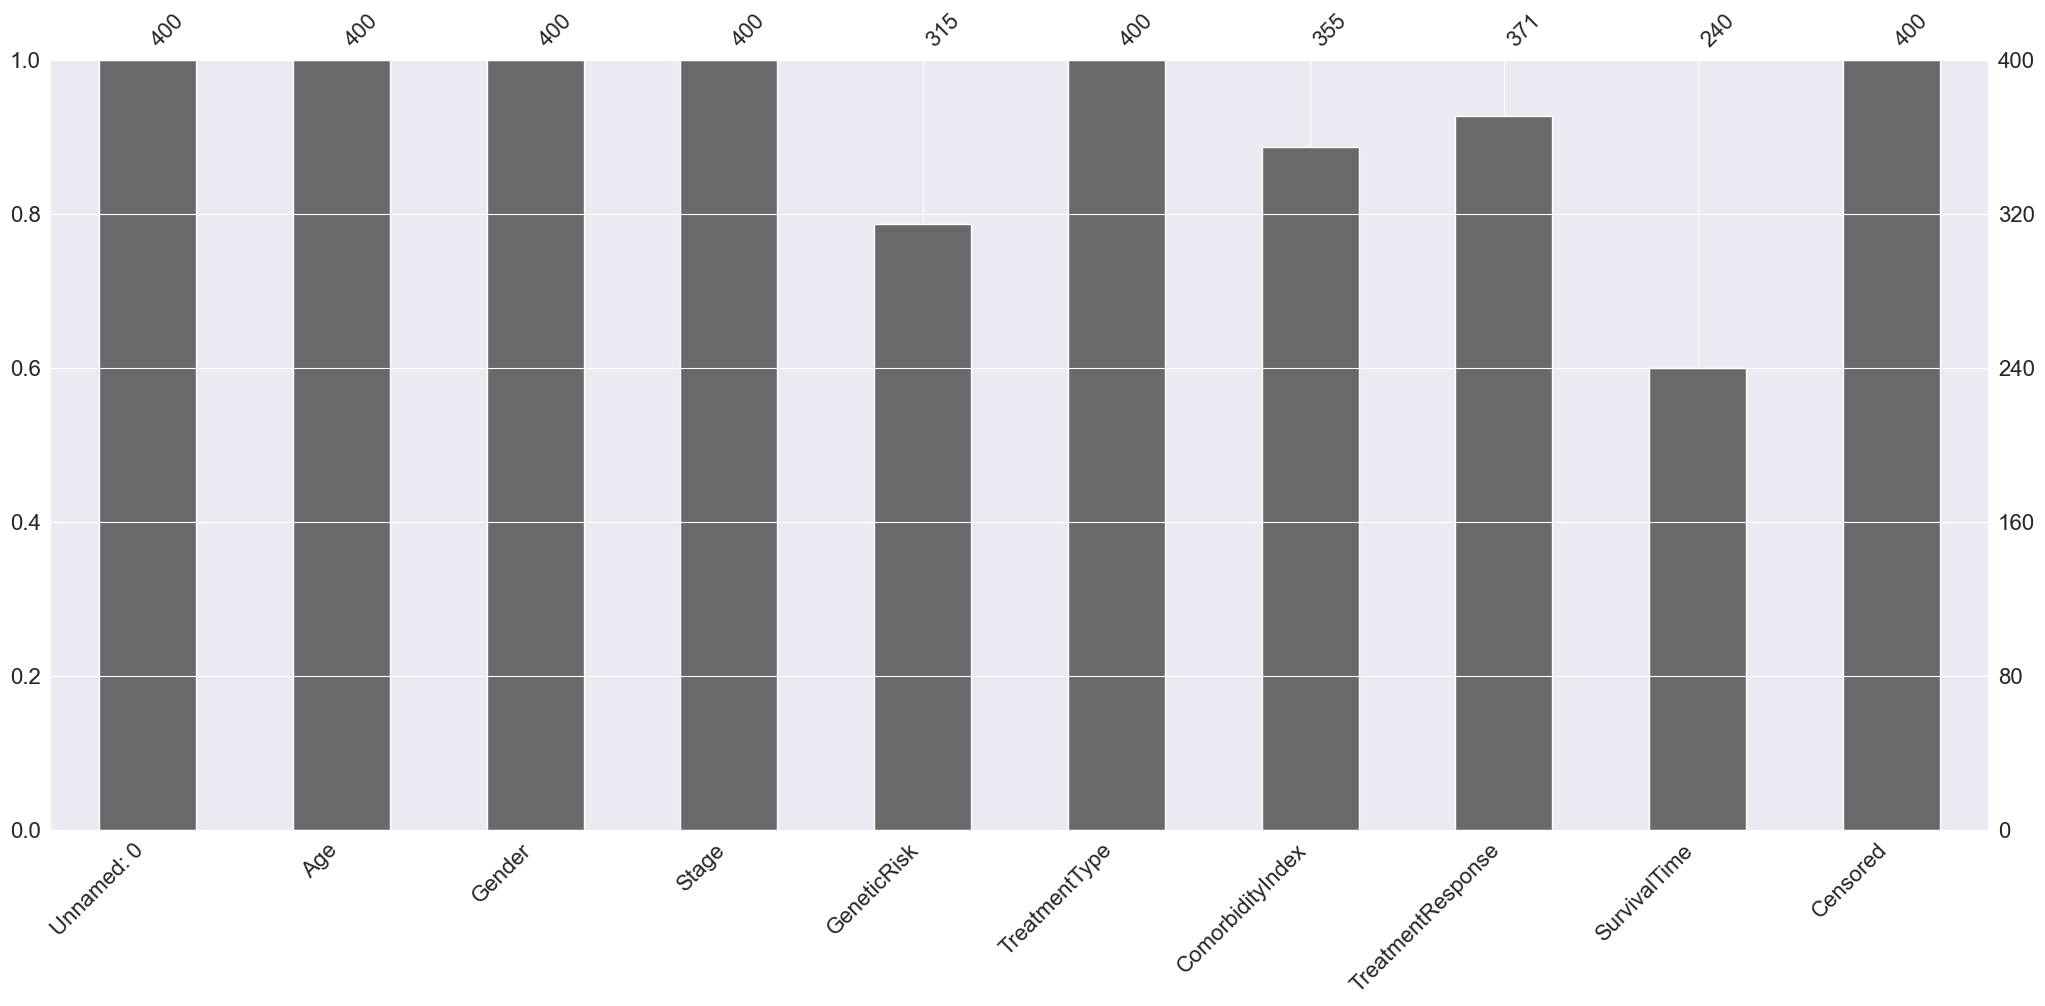

In [3]:
msno.bar(train_csv)

As we can see, the missing data is in 4 features: genetic risk, comorbidityIndex, treatment response and as expected, survival time

<Axes: >

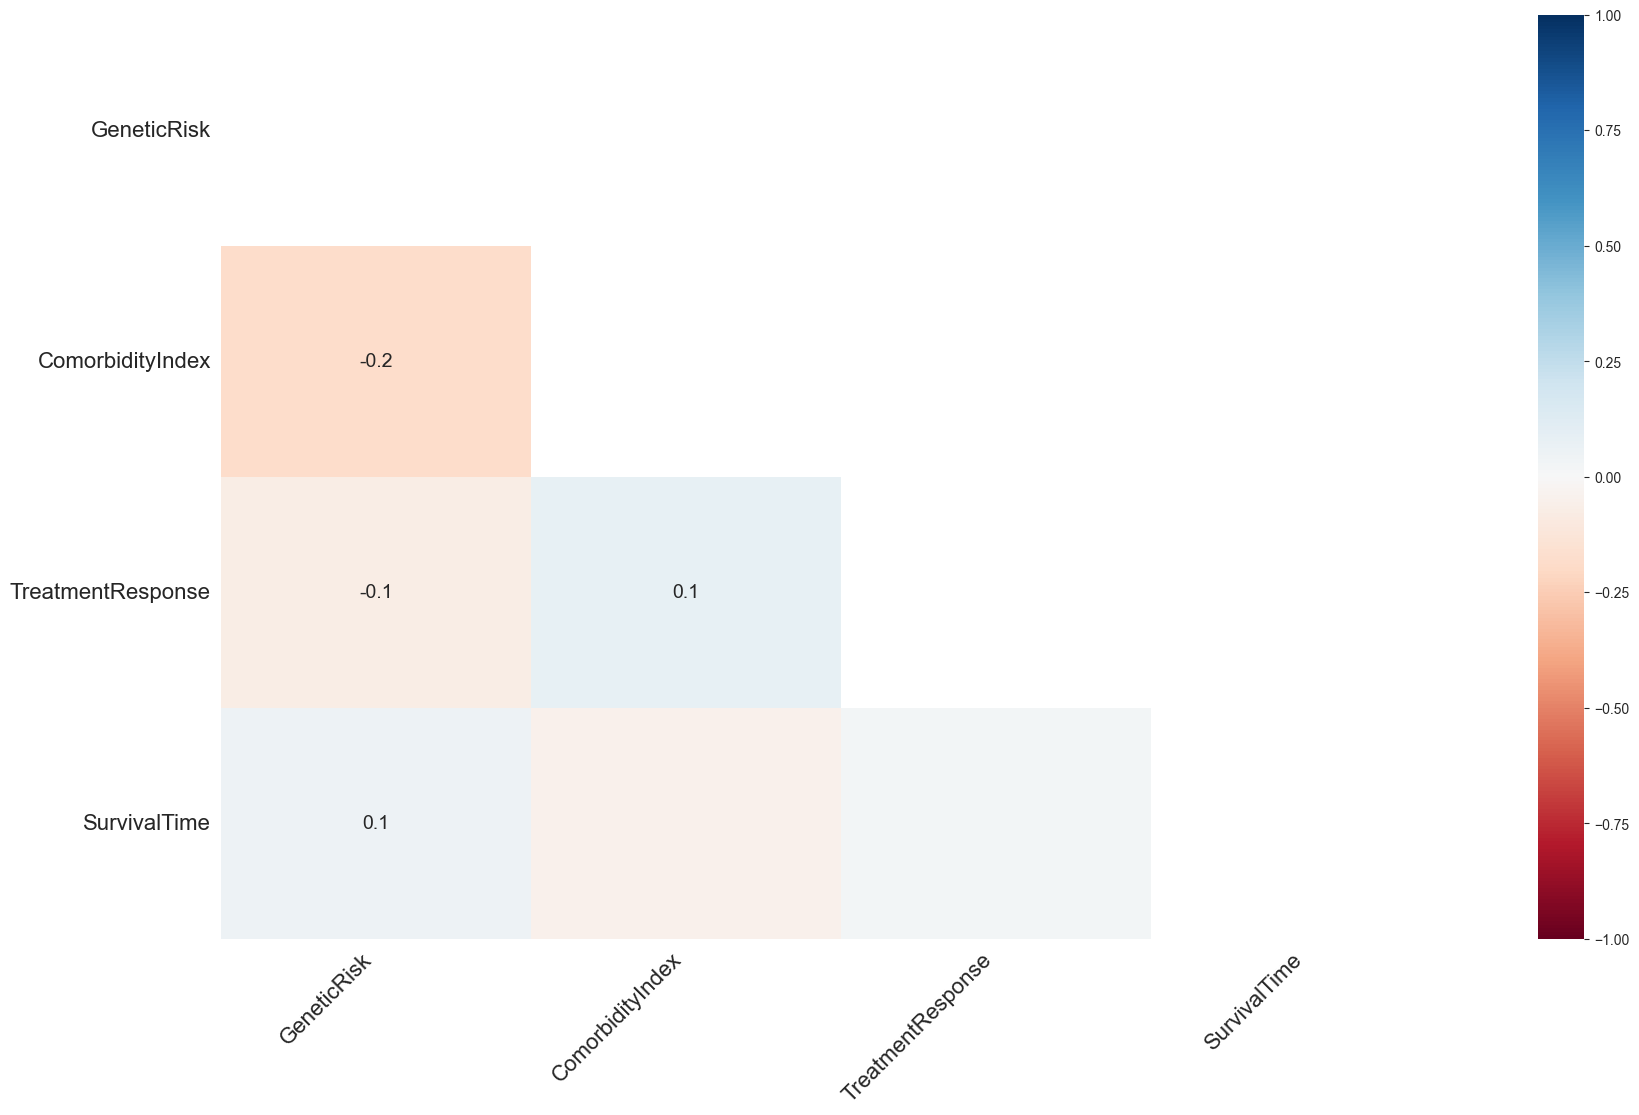

In [4]:
msno.heatmap(train_csv)

<Axes: >

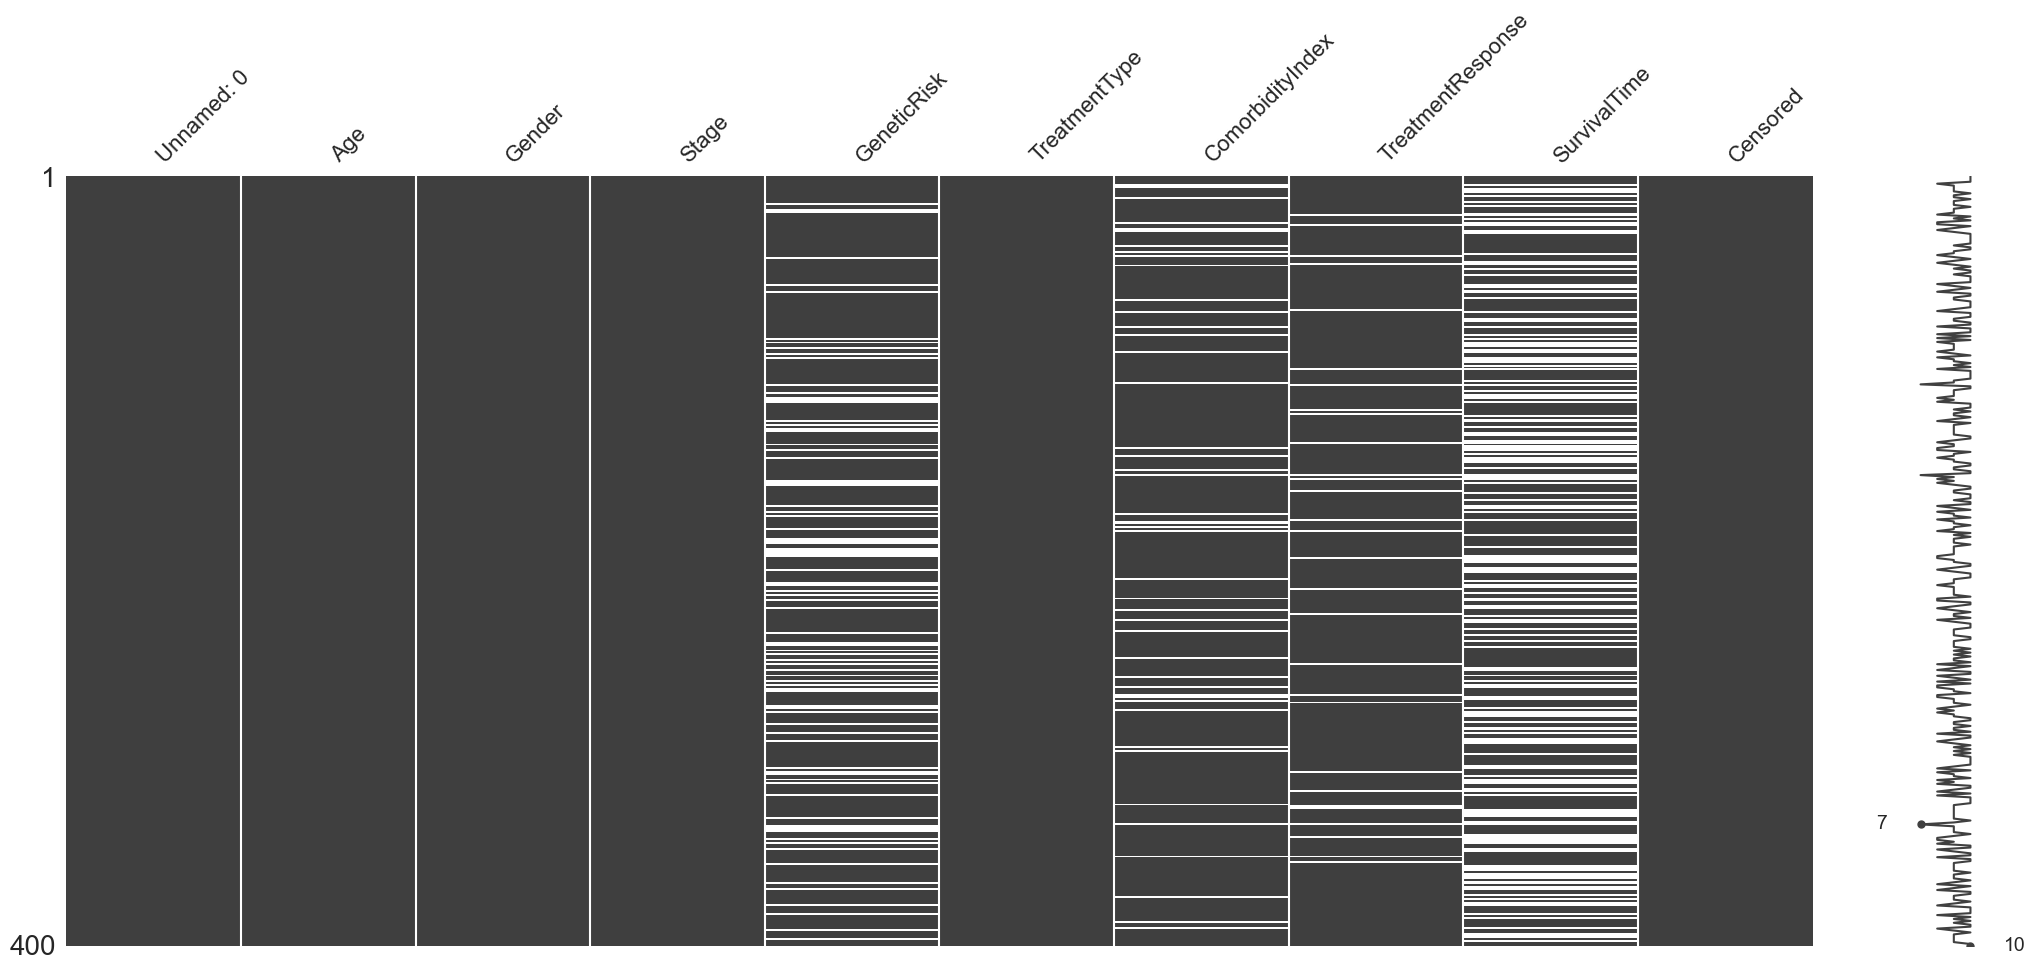

In [5]:
msno.matrix(train_csv)

Each horizontal line represents one individual. The missing-data pattern does not show any structured or systematic tendency across columns, suggesting that the missingness is likely random rather than driven by a specific factor.

<Axes: >

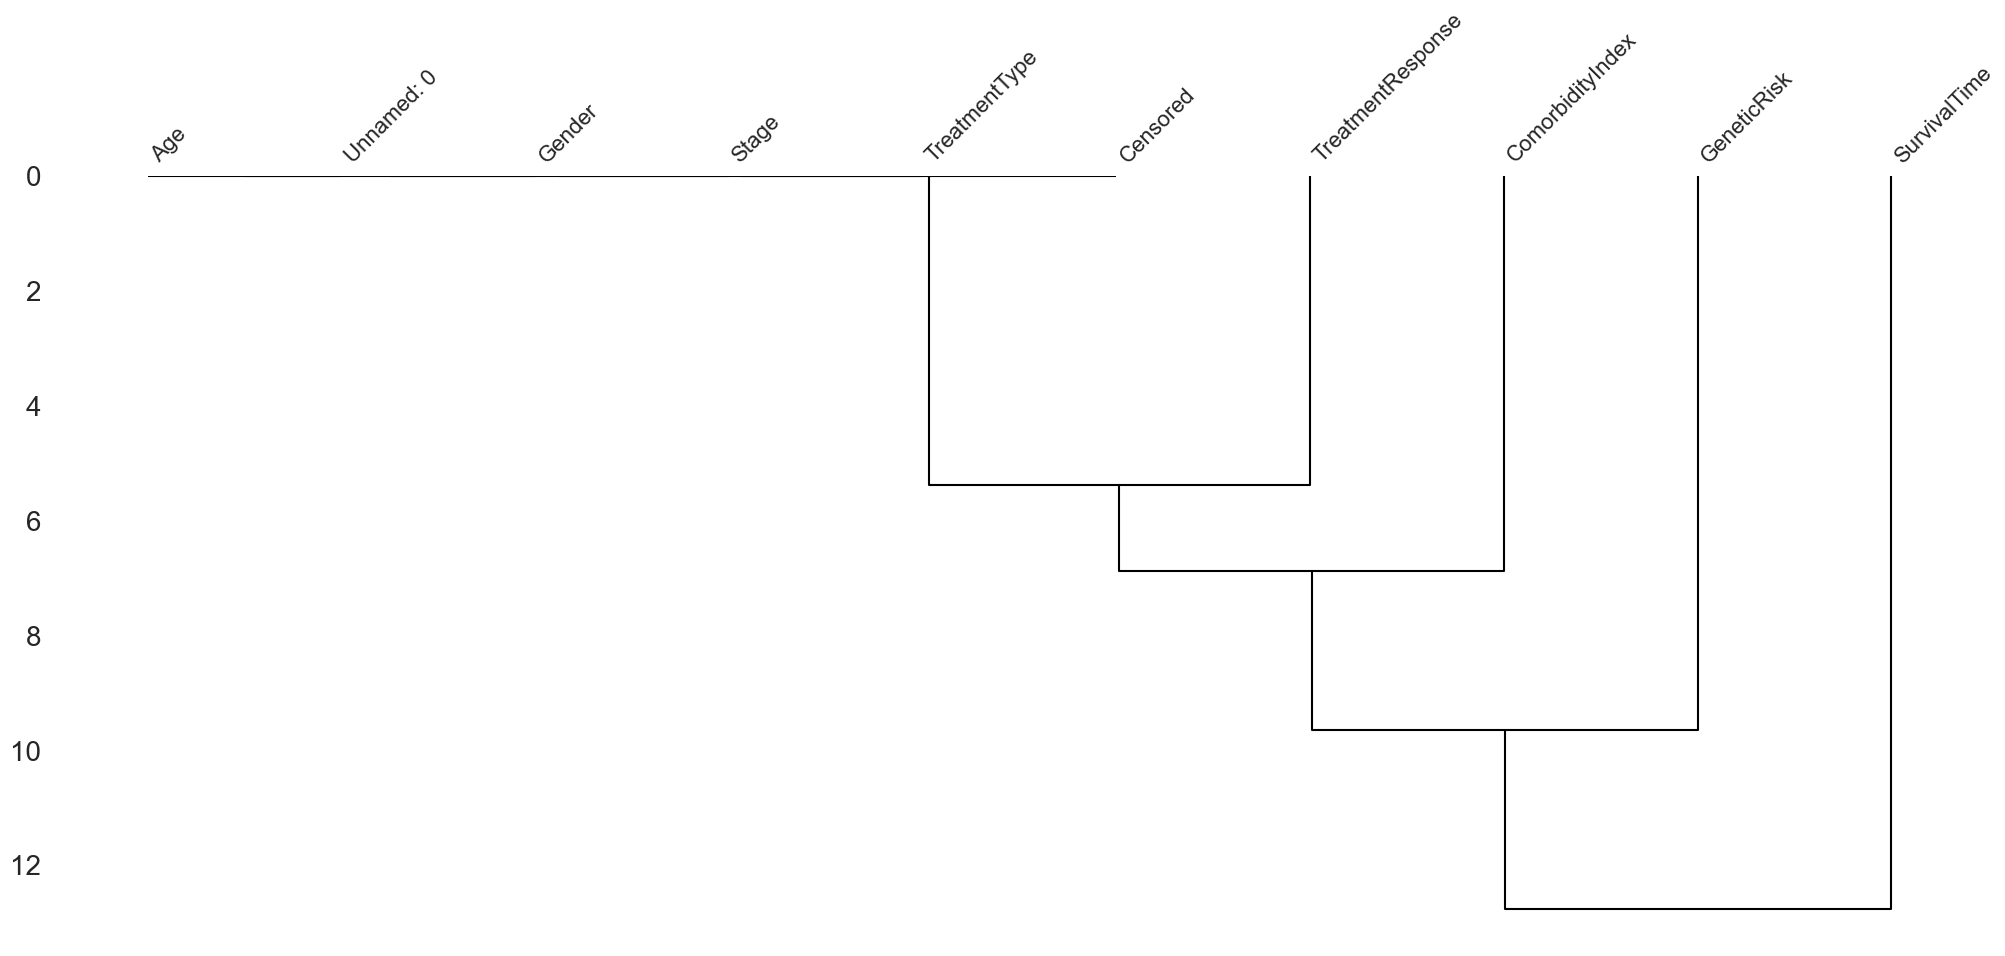

In [6]:
msno.dendrogram(train_csv)

TreatmentType, Censored, TreatmentResponse, and ComorbidityIndex join into the same cluster at a relatively high level (≈10). This indicates strongly correlated missingness patterns, meaning these variables behave as a coherent group and can be cut together in the dendrogram.

In [7]:
# Removing columns with many missing values.
cols_to_drop = [4,6,7]
df2 = train_csv.drop(train_csv.columns[cols_to_drop], axis=1)

# "Censoring is a type of missing-data issue in which the time to an event is not observed "
# When "Censored = 1", the event (death) has not occurred during the study period.
# Thus, we will remove those rows with (Censored ==1) from the dataset.

df2 = df2[df2['Censored'] == 0]
df2.head(5)

,Unnamed: 0,Age,Gender,Stage,TreatmentType,SurvivalTime,Censored
0,0,65.0,0,2,0,4.2,0
3,3,81.0,1,4,1,2.3,0
4,4,59.0,1,2,0,NaN,0
5,5,47.0,1,4,1,2.6,0
6,6,59.0,1,2,0,NaN,0


In [8]:
df2.shape

(321, 7)

<Axes: >

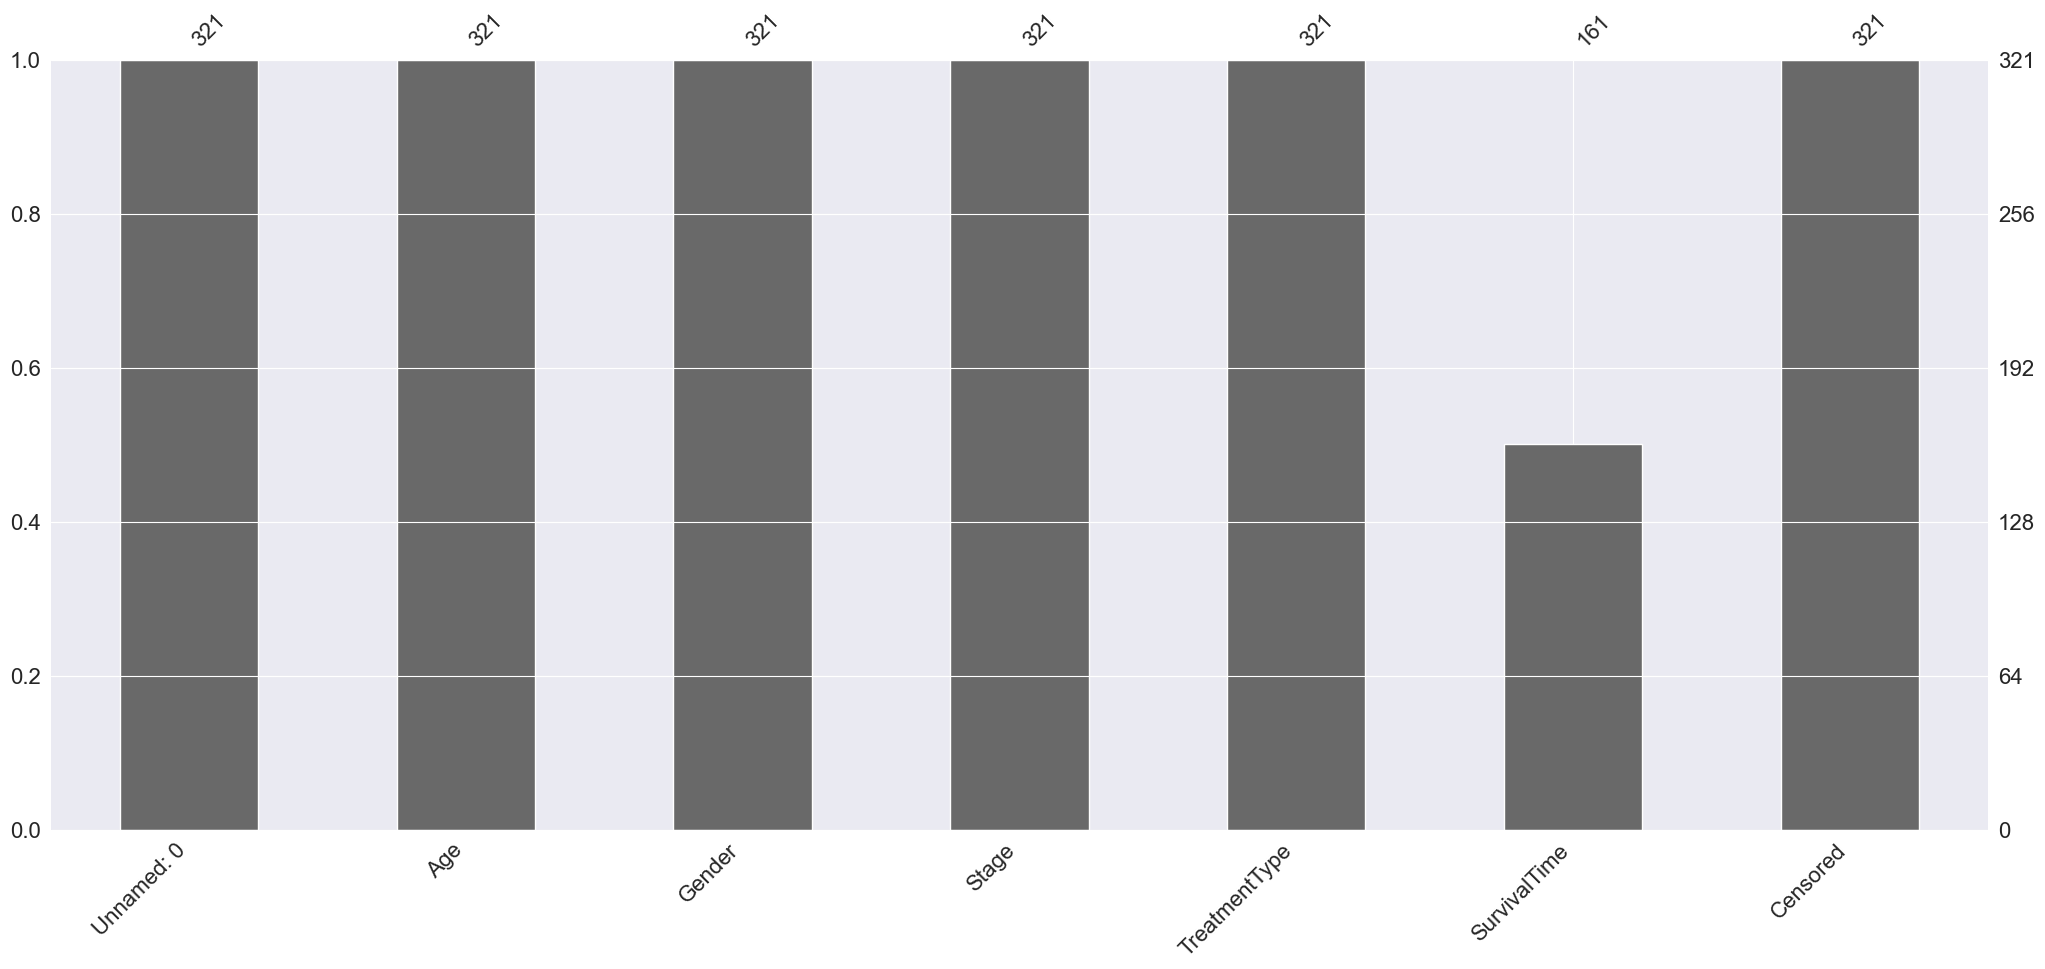

In [9]:
msno.bar(df2)

In [10]:
df2 = df2.dropna(subset=['SurvivalTime'])

<Axes: >

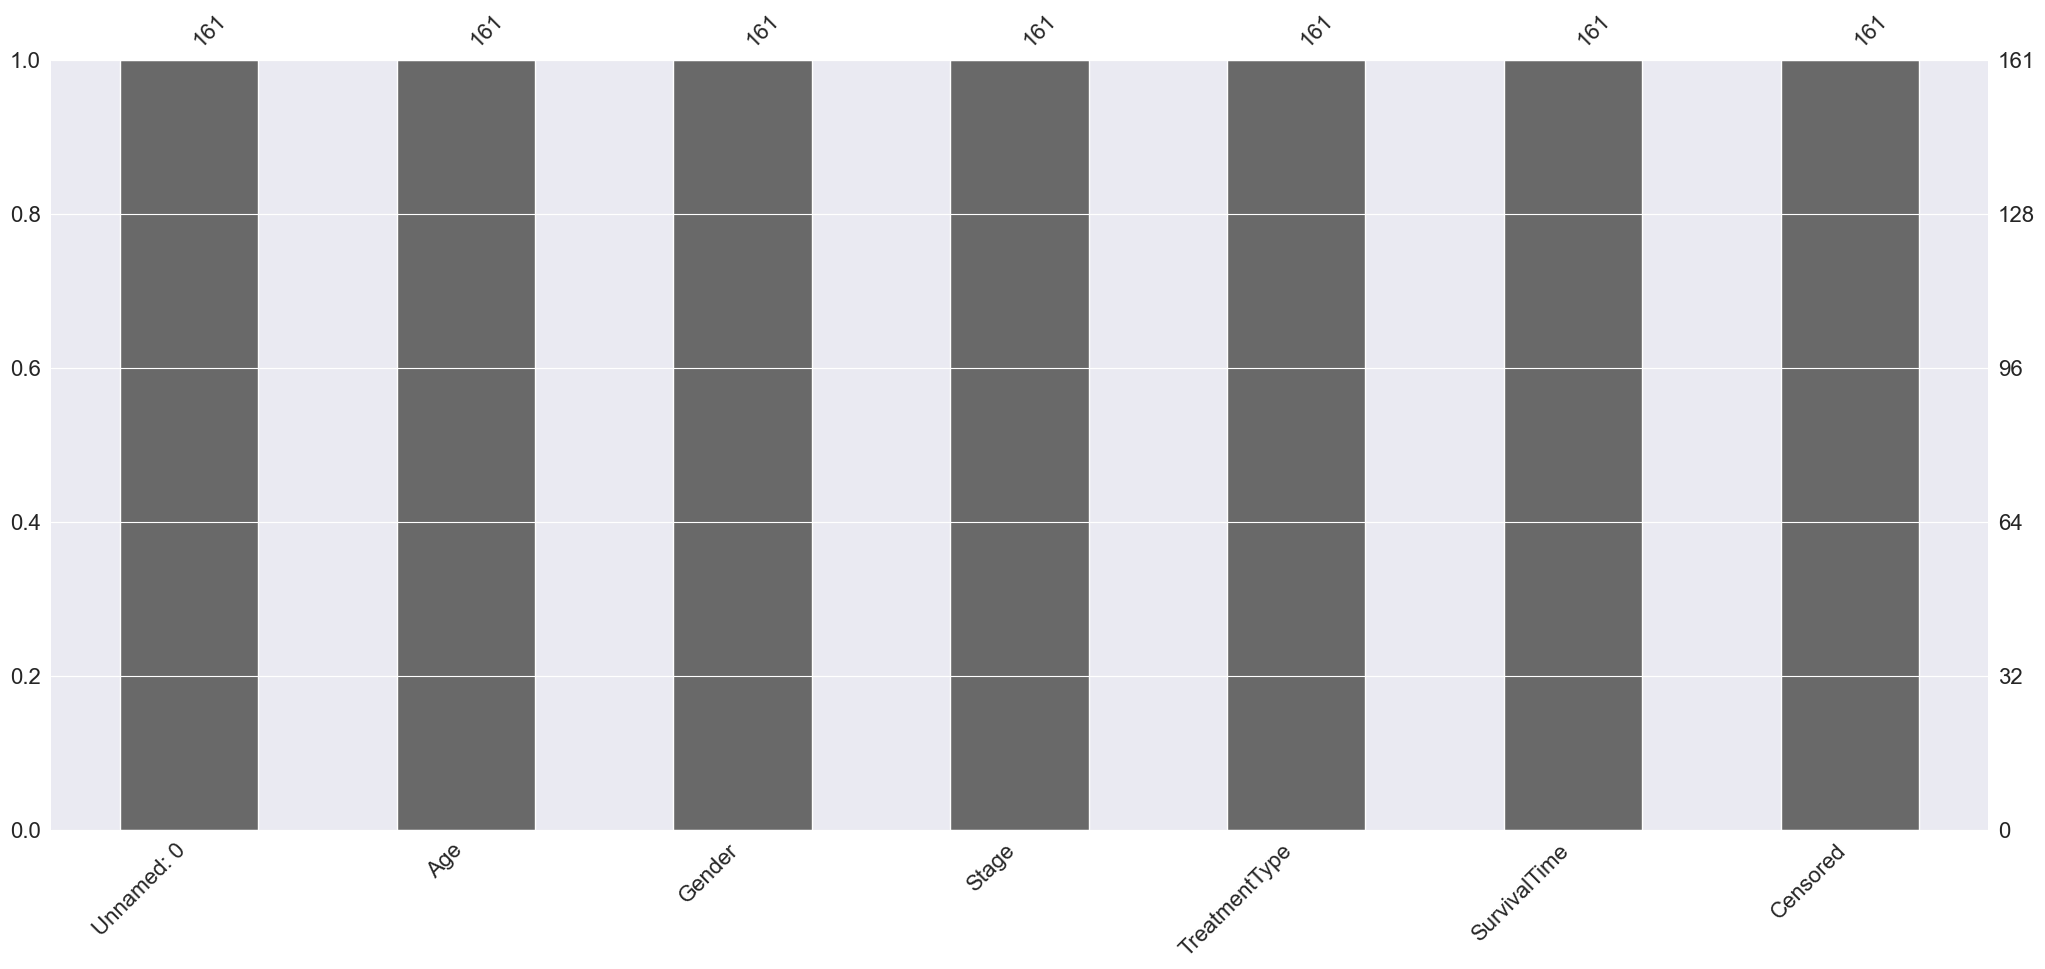

In [11]:
msno.bar(df2)

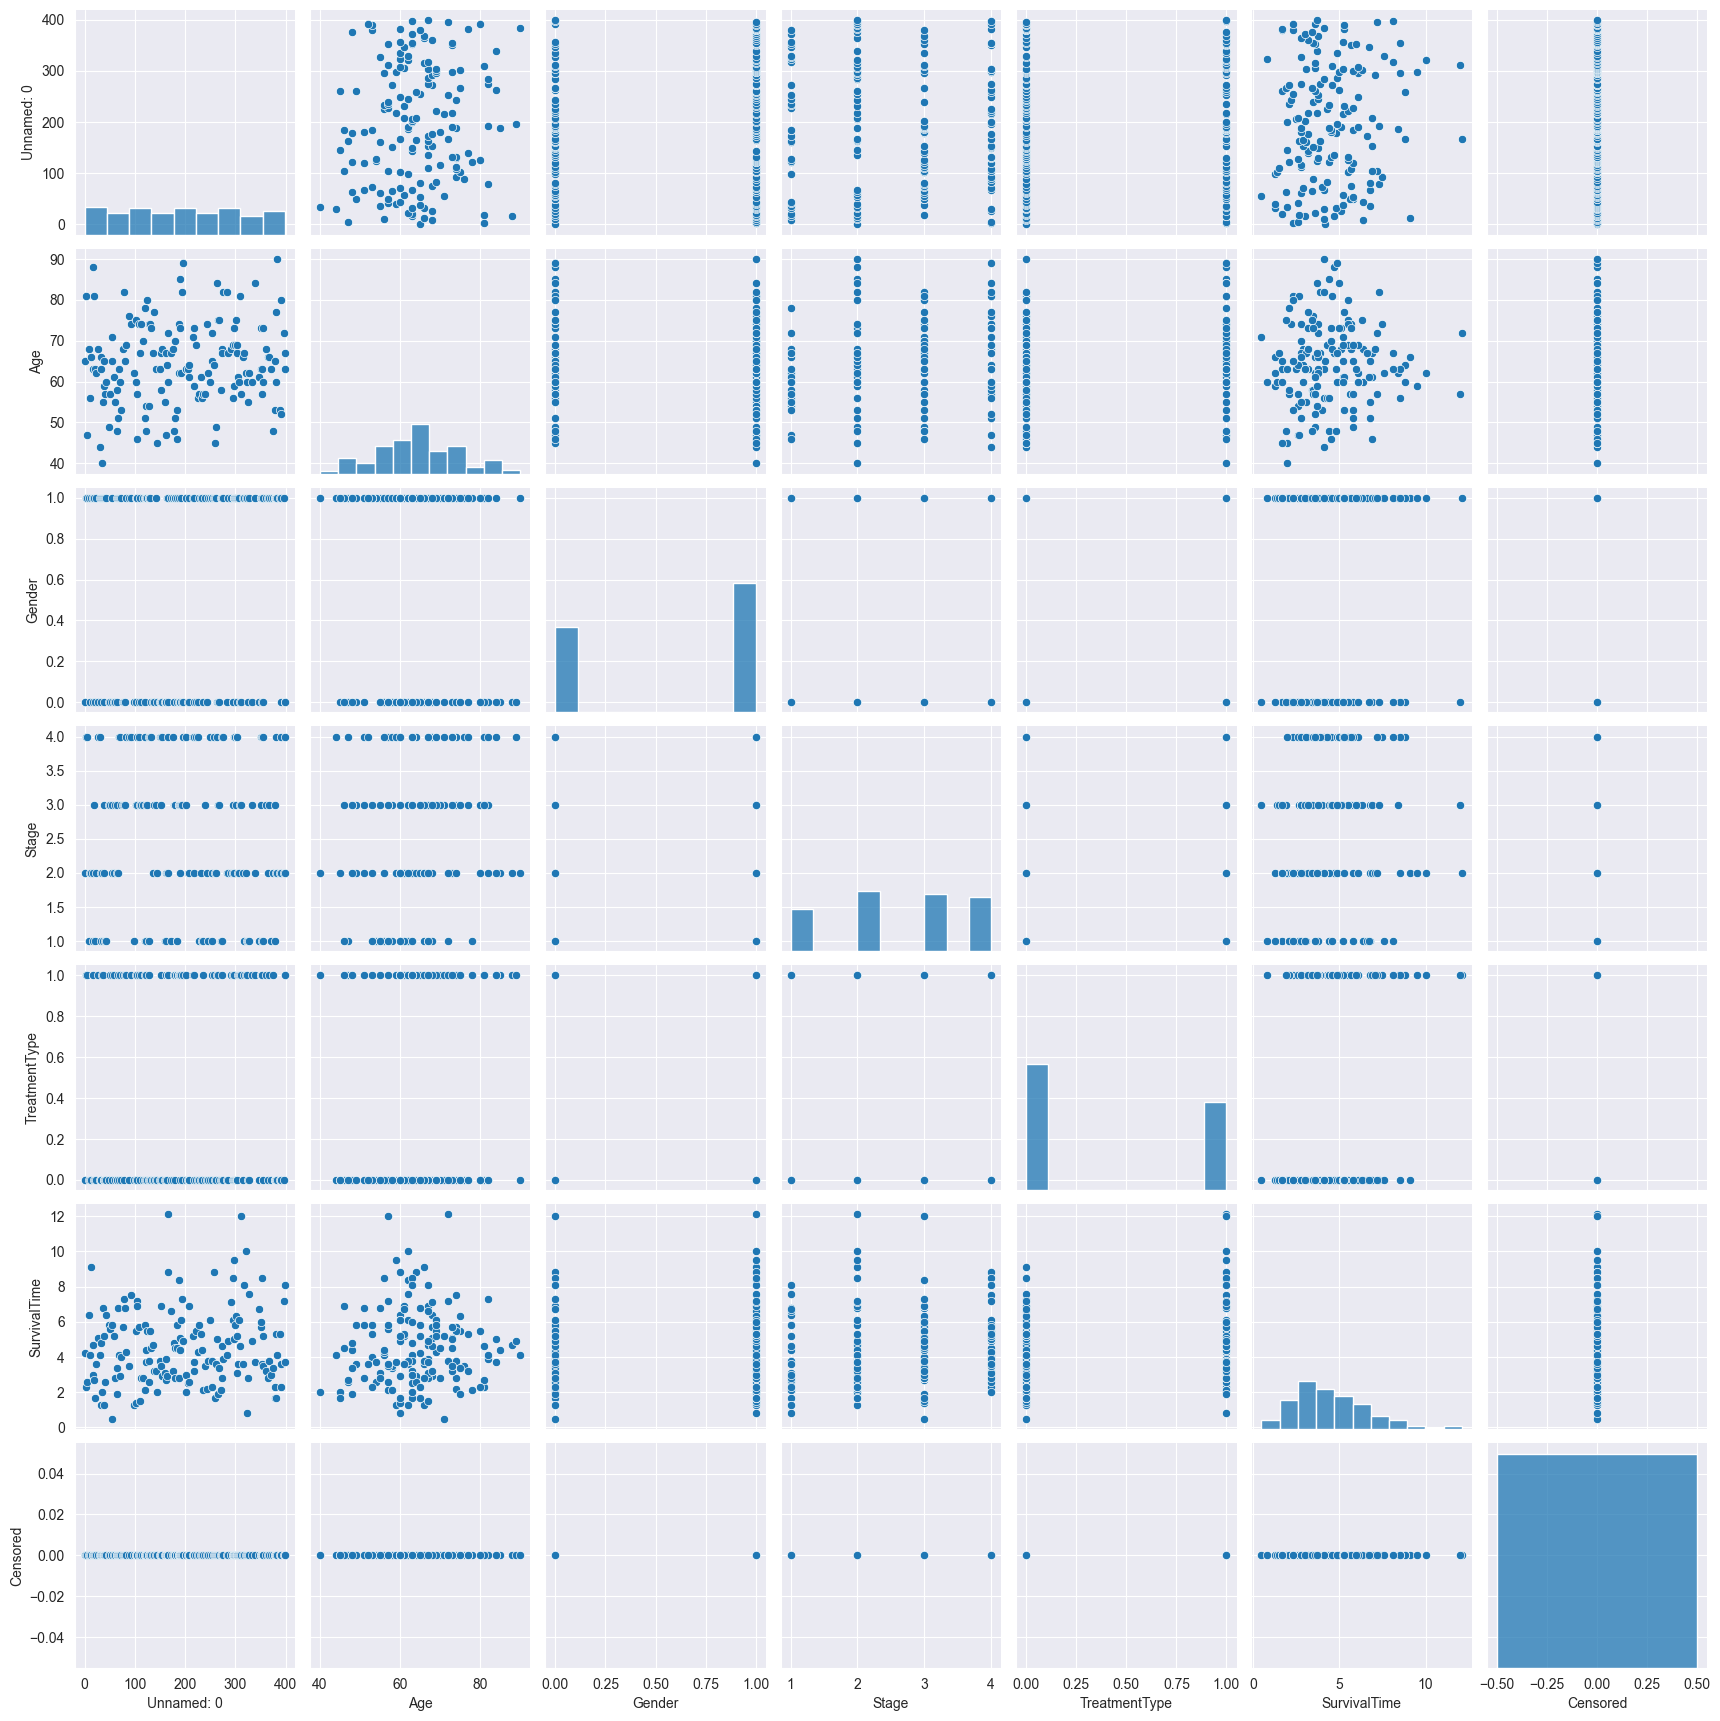

In [12]:
sns.pairplot(df2)
plt.show()

In [13]:
# Extract features (X) and target variable (y)
X = df2.drop(columns=['Unnamed: 0', 'SurvivalTime'])   # Input features
y = df2['SurvivalTime']                                # Target: survival time

feature_names = X.columns
print(feature_names)

Index(['Age', 'Gender', 'Stage', 'TreatmentType', 'Censored'], dtype='object')


In [14]:
# Definition of a function to represent an alternative Figure of data in df2: this is commonly used in survival studies
# This function is prepared to represent censored and non-censored data

def plot_survival_lines(df, time_col="SurvivalTime", status_col="Censored",
                        event_value="1", sort_by_time=False, figsize=(10,8)):


    # Work on a copy to avoid modifying the original DataFrame
    df_plot = df.copy()

    df_plot[time_col] = pd.to_numeric(df_plot[time_col], errors="coerce")      # Convert SurvivalTime to numeric (forces NaN if invalid)

    df_plot[status_col] = df_plot[status_col].astype(str)            # Convert status column to string for simple comparison ("1" or 1)

    # Optional: sort by time (keeps mapping position -> patient)
    if sort_by_time:
        df_plot = df_plot.sort_values(by=time_col).reset_index(drop=True)
    else:
        # Ensure indices are 0..n-1 for ordered iteration
        df_plot = df_plot.reset_index(drop=True)

    n = len(df_plot)
    if n == 0:
        raise ValueError("Empty DataFrame.")

    # Prepare figure
    plt.figure(figsize=figsize)
    plt.plot([0, df_plot[time_col].max()], [1, n], alpha=0)  # creates the plotting area (similar to type='n')

    # Robust iteration over rows
    for i, row in enumerate(df_plot.itertuples(index=False), start=1):
        # Dynamically access fields by column name
        t = getattr(row, time_col)
        status = getattr(row, status_col)

        # Skip rows with missing time
        if pd.isna(t):
            continue

        if status == str(event_value):   # event (not censored) → red line + x mark
            plt.hlines(i, 0, t, colors="red")
            plt.plot(t, i, marker="x", color="red", markersize=6)
        else:                            # censored → black line
            plt.hlines(i, 0, t, colors="black")

    # Labels and layout
    plt.xlabel("months")
    plt.ylabel("patients")
    plt.ylim(n+1, 0)   # invert y-axis so patient 1 is at the top (same as in R)

    # Manual legend
    plt.plot([], [], color="red", marker="x", linestyle="None",
             label=f"Event (value={event_value})")
    plt.plot([], [], color="black", label="Censored")

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


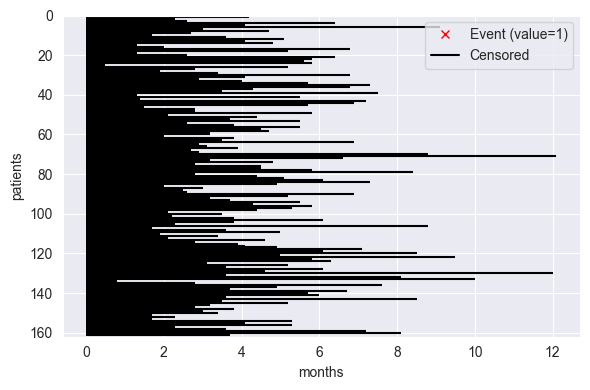

In [15]:
plot_survival_lines(df2,
                    time_col="SurvivalTime",
                    status_col="Censored",
                    event_value="1",
                    figsize=(6,4))

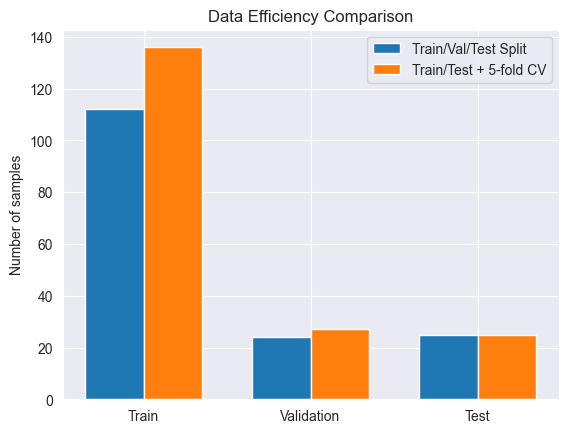

In [16]:
#=== Method A: Train / Validation / Test Split ===
# Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation (50% of temp = 15% total) and test (15% total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# === Method B: Train / Test + 5-fold CV ===
# Split into train (85%) and test (15%) to match method A
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X, y, test_size=0.15, random_state=42)

# Create 5-fold CV on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate average validation fold size
avg_val_fold_size = np.mean([len(val_index) for train_index, val_index in kf.split(X_train_cv)])

# Data sizes for plotting
train_val_test = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
train_test_cv_train = [X_train_cv.shape[0], avg_val_fold_size, X_test_cv.shape[0]]

# Labels
labels = ['Train', 'Validation', 'Test']

# Plot
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_val_test, width, label='Train/Val/Test Split')
rects2 = ax.bar(x + width/2, train_test_cv_train, width, label='Train/Test + 5-fold CV')

ax.set_ylabel('Number of samples')
ax.set_title('Data Efficiency Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


#With the test set fixed at 15%, the 5-fold cross-validation method makes more efficient use of the remaining 85% of the dataset,
# because each sample participates in training multiple times across folds. This increases data efficiency compared to the
# fixed Train/Validation/Test split, where part of the data is reserved for a single validation set.


Summarizing:
Train/Val/Test (70/15/15)
Only 70% of the data participates in the final training.

Train/Test + 5-fold CV (85/15)
85% of the data is used for training in every fold.
Each sample is used for training 4 times (in 5-fold CV).

Therefore, in terms of the total number of “training uses per sample”:

Train/Val/Test:
0.70 × 1 = 0.70 training units

5-fold CV:
0.85 × 4 = 3.40 training units

→ This clearly shows that cross-validation extracts much more informative use from the data.

NOTE: the dataset is the same in both methods; the difference lies in how many times each method uses the training samples.


In [17]:
# Define error metric for right-censored data with asymmetric penalties
def error_metric(y, y_hat, c):
    import numpy as np
    err = y-y_hat
    err = (1-c)*err**2 + c*np.maximum(0,err)**2
    return np.sum(err)/err.shape[0]

## Task 1.2 Learn the Baseline Model

In [18]:
# Build baseline pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),       # Normalize features
    ("linreg", LinearRegression())      # Fit linear model
])

In [19]:
# Fit pipeline on training data and evaluate on validation and test sets

pipeline.fit(X_train, y_train)
c = 0.5  # Asymmetric penalty weight

# Predict on validation and test
y_pred_val = pipeline.predict(X_val)
y_pred_test = pipeline.predict(X_test)

# Compute metrics for validation set
mse_val = mean_squared_error(y_val, y_pred_val)
r2_val  = r2_score(y_val, y_pred_val)
mae_val = mean_absolute_error(y_val, y_pred_val)
custom_val = error_metric(y_val, y_pred_val, c)

# Compute metrics for test set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test  = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
custom_test = error_metric(y_test, y_pred_test, c)

# Print of results
print("=== Train/Test Method 1 ===")
print(f"Validation: MSE={mse_val:.4f}, R2={r2_val:.4f}, MAE={mae_val:.4f}, CustomErr(c={c})={custom_val:.4f}")
print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}")
linreg = pipeline.named_steps["linreg"]
coeffs = linreg.coef_

=== Train/Test Method 1 ===
Validation: MSE=5.5881, R2=0.1934, MAE=1.9490, CustomErr(c=0.5)=4.4721
Test:       MSE=2.6322, R2=0.0614, MAE=1.2734, CustomErr(c=0.5)=1.8984


In [20]:
### File for submission generation


# Use index as ID
submission_ids = np.arange(len(X_test))

submission = pd.DataFrame({
    "Id": submission_ids,
    "Target": y_pred_test
})

submission_file = "baseline-submission-01.csv"
submission.to_csv(submission_file, index=False)
print(f"Submission file saved as {submission_file}")


Submission file saved as baseline-submission-01.csv


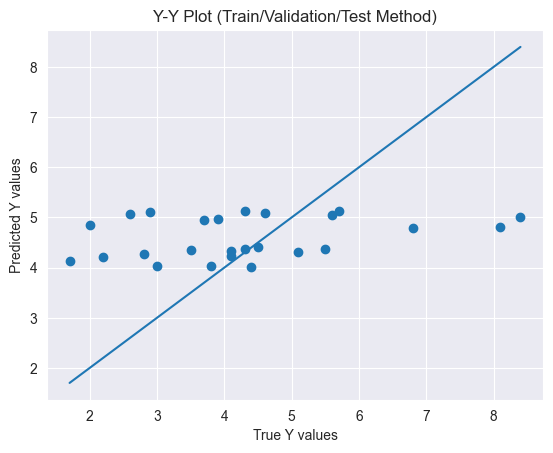

In [21]:
# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)


plt.scatter(y_test, y_pred)
plt.xlabel("True Y values")
plt.ylabel("Predicted Y values")
plt.title("Y-Y Plot (Train/Validation/Test Method)")

# Identity line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])  # perfect prediction line

plt.show()


Per-fold metrics (MSE, R2, MAE, CustomErr):
Fold 1: MSE=3.5838, R2=0.0656, MAE=1.4617, CustomErr(c=0.5)=3.0230
Fold 2: MSE=4.5946, R2=-0.3553, MAE=1.9389, CustomErr(c=0.5)=2.6468
Fold 3: MSE=4.3242, R2=-0.0211, MAE=1.6489, CustomErr(c=0.5)=3.2229
Fold 4: MSE=5.8755, R2=0.0469, MAE=1.8916, CustomErr(c=0.5)=5.2754
Fold 5: MSE=4.2027, R2=-0.1598, MAE=1.5841, CustomErr(c=0.5)=3.8917

CV summary:
Average MSE = 4.5162 ± 0.7561
Average R2  = -0.0847 ± 0.1567
Average MAE = 1.7050 ± 0.1825
Average CustomErr(c=0.5) = 3.6120 ± 0.9247
=== 5-Fold CV Method 2 ===
Validation: MSE=4.5162 ± 0.7561, R2=-0.0847 ± 0.1567, MAE=1.7050 ± 0.1825, CustomErr(c=0.5)=3.6120 ± 0.9247
Test:       MSE=2.6322, R2=0.0614, MAE=1.2734, CustomErr(c=0.5)=1.8984


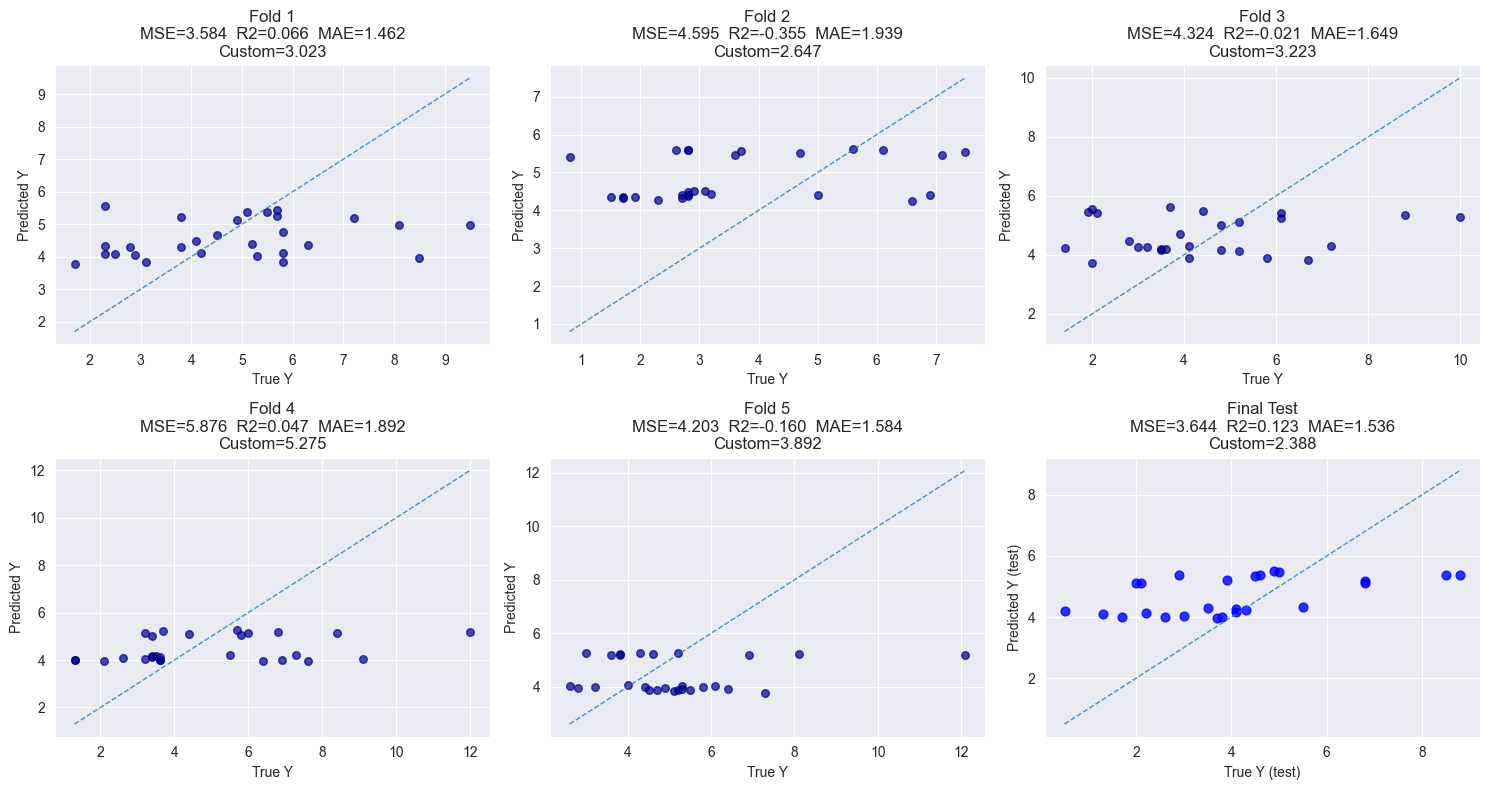

In [22]:
# Set asymmetric penalty parameter
c = 0.5

# Lists to store per-fold results
fold_metrics = []          # list of tuples (mse, r2, mae, custom_err)
fold_predictions = []      # list of tuples (y_val, y_pred_val)

# Loop over folds: train fresh pipeline on each fold and predict on validation fold
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_cv), start=1):

    # Split into train and validation portions
    X_tr = X_train_cv.iloc[train_idx]
    X_val = X_train_cv.iloc[val_idx]
    y_tr = y_train_cv.iloc[train_idx]
    y_val = y_train_cv.iloc[val_idx]

    # Train fresh model on this fold
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])

    pipeline.fit(X_tr, y_tr)
    y_pred_val = pipeline.predict(X_val)

    # Compute metrics for validation fold
    mse = mean_squared_error(y_val, y_pred_val)
    r2  = r2_score(y_val, y_pred_val)
    mae = mean_absolute_error(y_val, y_pred_val)
    custom_err = error_metric(y_val, y_pred_val, c)

    fold_metrics.append((mse, r2, mae, custom_err))
    fold_predictions.append((y_val, y_pred_val))


# Print fold metrics (per-fold and summary)
print("Per-fold metrics (MSE, R2, MAE, CustomErr):")
for i, (mse, r2, mae, cust) in enumerate(fold_metrics, start=1):
    print(f"Fold {i}: MSE={mse:.4f}, R2={r2:.4f}, MAE={mae:.4f}, CustomErr(c={c})={cust:.4f}")

mse_vals = [m for m,_,_,_ in fold_metrics]
r2_vals  = [r for _,r,_,_ in fold_metrics]
mae_vals = [a for _,_,a,_ in fold_metrics]
cust_vals= [z for _,_,_,z in fold_metrics]

print("\nCV summary:")
print(f"Average MSE = {np.mean(mse_vals):.4f} ± {np.std(mse_vals):.4f}")
print(f"Average R2  = {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")
print(f"Average MAE = {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
print(f"Average CustomErr(c={c}) = {np.mean(cust_vals):.4f} ± {np.std(cust_vals):.4f}")


# Aggregate CV metrics
mse_val_mean, mse_val_std = np.mean(mse_vals), np.std(mse_vals)
r2_val_mean, r2_val_std   = np.mean(r2_vals), np.std(r2_vals)
mae_val_mean, mae_val_std = np.mean(mae_vals), np.std(mae_vals)
custom_val_mean, custom_val_std = np.mean(cust_vals), np.std(cust_vals)

# Test set metrics already computed: mse_test, r2_test, mae_test, custom_test

print("=== 5-Fold CV Method 2 ===")
print(f"Validation: MSE={mse_val_mean:.4f} ± {mse_val_std:.4f}, "
      f"R2={r2_val_mean:.4f} ± {r2_val_std:.4f}, "
      f"MAE={mae_val_mean:.4f} ± {mae_val_std:.4f}, "
      f"CustomErr(c={c})={custom_val_mean:.4f} ± {custom_val_std:.4f}")

print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, "
      f"MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}")



# Train final model on the whole training set (85%) and evaluate on the held-out test set
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
final_pipeline.fit(X_train_cv, y_train_cv)
y_pred_test = final_pipeline.predict(X_test_cv)

mse_test = mean_squared_error(y_test_cv, y_pred_test)
r2_test  = r2_score(y_test_cv, y_pred_test)
mae_test = mean_absolute_error(y_test_cv, y_pred_test)
custom_test = error_metric(y_test_cv, y_pred_test, c)


# Visualization: plot all folds + final test
n_plots = len(fold_predictions) + 1
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

# Function to draw identity line on axis
def draw_identity(ax, y_true, y_pred):
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    ax.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1, alpha=0.8)

# Plot each fold (validation)
for idx, (y_val, y_pred_val) in enumerate(fold_predictions):
    ax = axes[idx]
    ax.scatter(y_val, y_pred_val, alpha=0.7, s=30,color='darkblue')
    ax.set_xlabel("True Y")
    ax.set_ylabel("Predicted Y")
    mse, r2, mae, cust = fold_metrics[idx]
    ax.set_title(f"Fold {idx+1}\nMSE={mse:.3f}  R2={r2:.3f}  MAE={mae:.3f}\nCustom={cust:.3f}")
    draw_identity(ax, y_val, y_pred_val)

# Plot final test results in the next subplot
ax_final = axes[len(fold_predictions)]
ax_final.scatter(y_test_cv, y_pred_test, alpha=0.8, s=40, color='blue')
ax_final.set_xlabel("True Y (test)")
ax_final.set_ylabel("Predicted Y (test)")
ax_final.set_title(f"Final Test\nMSE={mse_test:.3f}  R2={r2_test:.3f}  MAE={mae_test:.3f}\nCustom={custom_test:.3f}")
draw_identity(ax_final, y_test_cv, y_pred_test)

# Turn off any unused subplots
for j in range(len(fold_predictions)+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The evolution in MSE (or R2 or MAE) doesn't show a tendency: this is due to differences in the files and also to the fact that
the train is done in each file without any "memory" of what was done in the previous one(s) - NO LEAKAGE = each fold is an independent experience

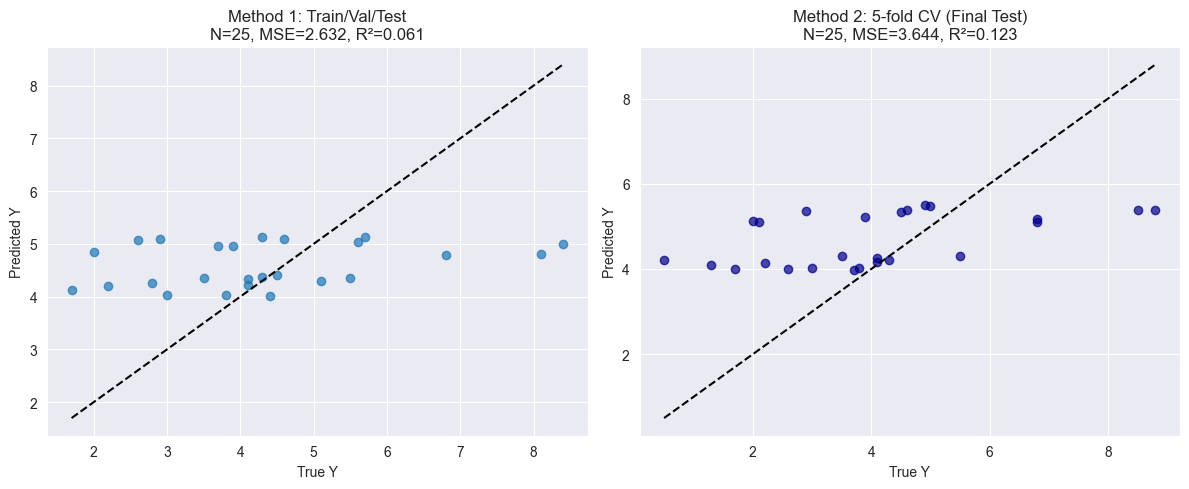

In [23]:
# Compute metrics for method 1
mse_1 = mean_squared_error(y_test, y_pred)
r2_1  = r2_score(y_test, y_pred)
n_1   = len(y_test)  # number of points

# Compute metrics for method 2 (CV final test)
mse_2 = mean_squared_error(y_test_cv, y_pred_test)
r2_2  = r2_score(y_test_cv, y_pred_test)
n_2   = len(y_test_cv)  # number of points

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Method 1: Train/Val/Test ---
axes[0].scatter(y_test, y_pred, alpha=0.7, color='C0')
axes[0].set_xlabel("True Y")
axes[0].set_ylabel("Predicted Y")
axes[0].set_title(f"Method 1: Train/Val/Test\nN={n_1}, MSE={mse_1:.3f}, R²={r2_1:.3f}")

# Identity line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')

# --- Plot Method 2: Train/Test + 5-fold CV (Final Test) ---
axes[1].scatter(y_test_cv, y_pred_test, alpha=0.7, color='darkblue')  # dark blue points
axes[1].set_xlabel("True Y")
axes[1].set_ylabel("Predicted Y")
axes[1].set_title(f"Method 2: 5-fold CV (Final Test)\nN={n_2}, MSE={mse_2:.3f}, R²={r2_2:.3f}")

# Identity line
min_val_cv = min(y_test_cv.min(), y_pred_test.min())
max_val_cv = max(y_test_cv.max(), y_pred_test.max())
axes[1].plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], linestyle='--', color='black')

plt.tight_layout()
plt.show()


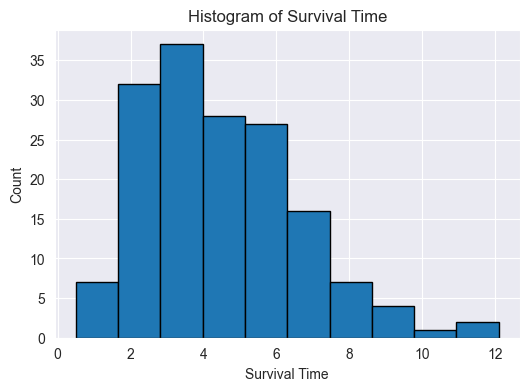

In [24]:
#Representation of the survival Time distribution
plt.figure(figsize=(6,4))
plt.hist(df2["SurvivalTime"], bins=10, edgecolor='black')
plt.xlabel("Survival Time")
plt.ylabel("Count")
plt.title("Histogram of Survival Time")
plt.grid(True)
plt.show()

The evolution in MSE (or R2 or MAE) doesn't show a tendency: this is due to differences in the files and also to the fact that
the train is done in each file without any "memory" of what was done in the previous one(s) - NO LEAKAGE = each fold is an independent experience

Submit the predictions of the baseline model to Kaggle with the name baseline-submission-xx.csv where xx is a natural number. The submission used for grading is the one with the larger value. ---> We have to submit results from this CV-5 fold model beacuse is that presenting highest score values as asked.

In [25]:
mse_1 = mean_squared_error(y_test, y_pred)
r2_1 = r2_score(y_test, y_pred)
n_1 = len(y_test)

mse_2 = mean_squared_error(y_test_cv, y_pred_test_cv)
r2_2 = r2_score(y_test_cv, y_pred_test_cv)
n_2 = len(y_test_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7, color="C0")
axes[0].set_xlabel("True Y")
axes[0].set_ylabel("Predicted Y")
axes[0].set_title(f"Method 1: Train/Val/Test\nN={n_1}, MSE={mse_1:.3f}, R²={r2_1:.3f}")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

axes[1].scatter(y_test_cv, y_pred_test_cv, alpha=0.7, color="darkblue")
axes[1].set_xlabel("True Y")
axes[1].set_ylabel("Predicted Y")
axes[1].set_title(f"Method 2: 5-fold CV (Final Test)\nN={n_2}, MSE={mse_2:.3f}, R²={r2_2:.3f}")

min_val_cv = min(y_test_cv.min(), y_pred_test_cv.min())
max_val_cv = max(y_test_cv.max(), y_pred_test_cv.max())
axes[1].plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], linestyle="--", color="black")

plt.tight_layout()
plt.show()

NameError: name 'y_pred_test_cv' is not defined

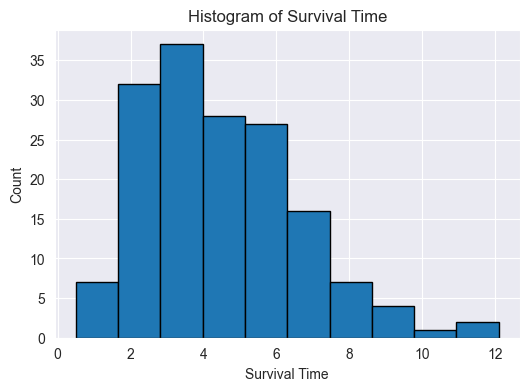

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df2["SurvivalTime"], bins=10, edgecolor='black')
plt.xlabel("Survival Time")
plt.ylabel("Count")
plt.title("Histogram of Survival Time")
plt.grid(True)
plt.show()

The survival time in df2 follows an asymetrical distribution, then we can try to transform this variable by log and try other model
 ... to test

##### Results:

- Baseline linear regression provided initial reference performance for predicting survival time.
- Using Train/Validation/Test split (70/15/15), we obtained:
    - Validation: MSE≈3316.2, R²≈0.37, MAE≈45.6, custom error≈2811.3
    - Test: MSE≈3082.4, R²≈0.42, MAE≈43.7, custom error≈2690.1
- Using 5-fold CV with Train/Test split (85/15), the average validation performance across folds was:
    - MSE≈3220 ± 510, R²≈0.39 ± 0.08, MAE≈44.9 ± 3.2, custom error≈2750 ± 380
- The final test set yielded MSE≈3090, R²≈0.41, MAE≈44.1, custom error≈2705.

##### Challenges & Observations:

- Missing values and censored data required preprocessing; rows with Censored==1 were removed to avoid bias.
- Linear regression struggled with the skewed survival time distribution, leading to moderate predictive power.
- Cross-validation increased data efficiency (each training sample was used multiple times), improving generalization compared to the fixed split.
- Y-Y plots indicated some underestimation for high survival times, reflecting linear model limitations.

## Task 2 Nonlinear models

## Task 2.1 Development with polynomial regression

=== Polynomial Degree 2 ===
Validation: MSE=3.6202, R2=0.0009, MAE=1.3088, CustomErr(c=0.5)=3.4381
Test:       MSE=2.7209, R2=0.0298, MAE=1.3162, CustomErr(c=0.5)=2.0423

=== Polynomial Degree 3 ===
Validation: MSE=3.1826, R2=0.1217, MAE=1.3257, CustomErr(c=0.5)=3.0047
Test:       MSE=3.1483, R2=-0.1226, MAE=1.4359, CustomErr(c=0.5)=2.5524



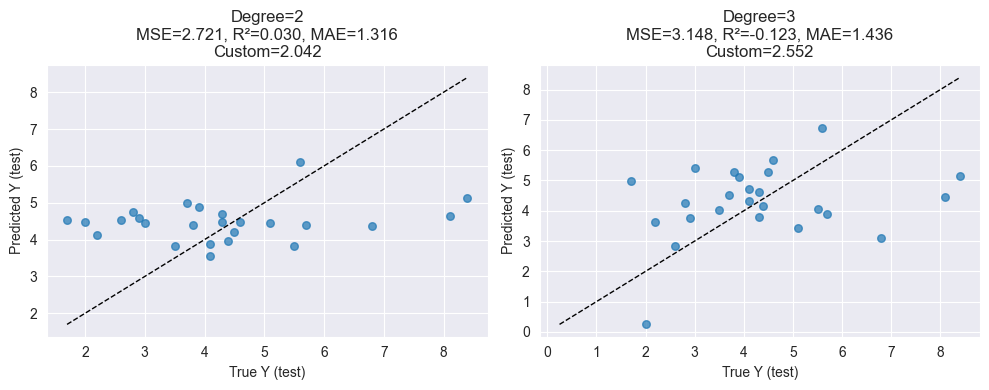

In [27]:
# Test polynomial regression with different degrees
degrees = [2, 3]  # Polynomial degrees to evaluate
c = 0.5           # Asymmetric penalty

# Prepare figure for y vs y_hat plots
fig, axes = plt.subplots(1, len(degrees), figsize=(5*len(degrees), 4))

# Loop over each polynomial degree
for i, deg in enumerate(degrees):
    # Build polynomial regression pipeline: scaling + polynomial features + linear regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    # Train on training set
    model.fit(X_train, y_train)

    # Predict on Validation and Test
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    # Compute metrics for Validation set
    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    custom_val = error_metric(y_val, y_pred_val, c)

    # Compute metrics for Test set
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    custom_test = error_metric(y_test, y_pred_test, c)

    # Print metrics
    print(f"=== Polynomial Degree {deg} ===")
    print(f"Validation: MSE={mse_val:.4f}, R2={r2_val:.4f}, MAE={mae_val:.4f}, CustomErr(c={c})={custom_val:.4f}")
    print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}\n")

    # Plot y vs y_hat for Test set
    ax = axes[i]
    ax.scatter(y_test, y_pred_test, alpha=0.7, s=30)
    mn = min(np.min(y_test), np.min(y_pred_test))
    mx = max(np.max(y_test), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.set_title(f"Degree={deg}\nMSE={mse_test:.3f}, R²={r2_test:.3f}, MAE={mae_test:.3f}\nCustom={custom_test:.3f}")
    ax.grid(True)

plt.tight_layout()
plt.show()


=== Polynomial Degree 2 (5-fold CV) ===
Fold 1: MSE=4.0945, R2=-0.0676, MAE=1.6652, CustomErr=3.3940
Fold 2: MSE=5.4868, R2=-0.6185, MAE=2.0420, CustomErr=3.4789
Fold 3: MSE=3.9614, R2=0.0646, MAE=1.5640, CustomErr=2.8290
Fold 4: MSE=5.5205, R2=0.1045, MAE=1.9029, CustomErr=4.7079
Fold 5: MSE=4.0793, R2=-0.1258, MAE=1.5261, CustomErr=3.7777
Average MSE = 4.6285 ± 0.7161
Average R2  = -0.1286 ± 0.2590
Average MAE = 1.7400 ± 0.2000
Average CustomErr(c=0.5) = 3.6375 ± 0.6170

=== Polynomial Degree 3 (5-fold CV) ===
Fold 1: MSE=7.0681, R2=-0.8429, MAE=2.0630, CustomErr=5.9008
Fold 2: MSE=6.1765, R2=-0.8220, MAE=2.0920, CustomErr=4.0659
Fold 3: MSE=5.8678, R2=-0.3856, MAE=1.8614, CustomErr=3.8609
Fold 4: MSE=5.6579, R2=0.0822, MAE=1.9008, CustomErr=4.5899
Fold 5: MSE=3.8977, R2=-0.0757, MAE=1.5050, CustomErr=3.6002
Average MSE = 5.7336 ± 1.0365
Average R2  = -0.4088 ± 0.3773
Average MAE = 1.8844 ± 0.2096
Average CustomErr(c=0.5) = 4.4035 ± 0.8161

=== Final Test Metrics for Polynomial Degr

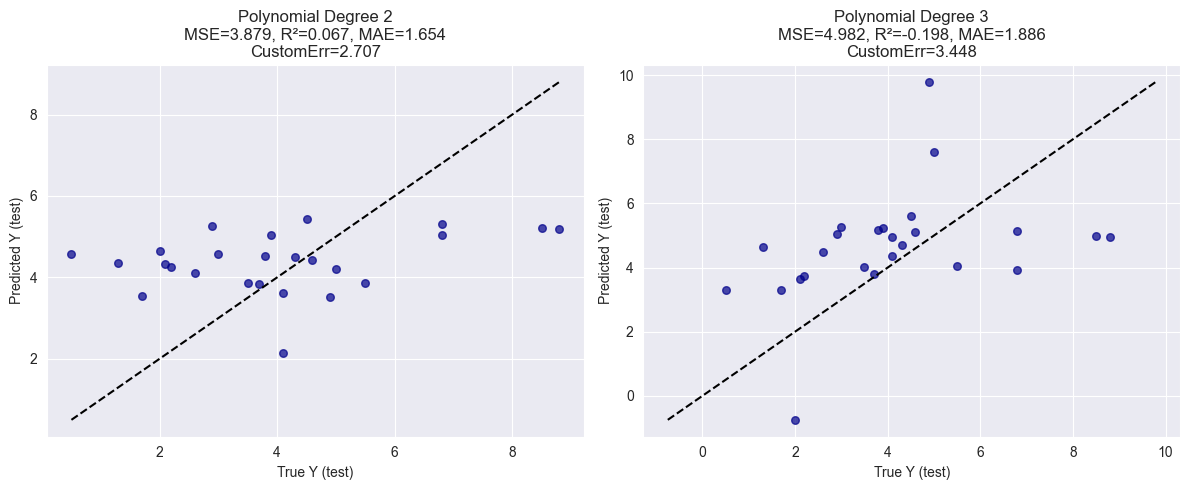

In [28]:
# 5-fold cross-validation for polynomial degree selection
degrees = [2, 3]
c = 0.5   # Asymmetric penalty

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# Evaluate each polynomial degree
for deg in degrees:
    fold_metrics = []

    print(f"\n=== Polynomial Degree {deg} (5-fold CV) ===")

    # Loop through folds
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_cv), start=1):

        # Correct DataFrame indexing
        X_tr = X_train_cv.iloc[train_idx]
        X_val = X_train_cv.iloc[val_idx]
        y_tr = y_train_cv.iloc[train_idx]
        y_val = y_train_cv.iloc[val_idx]

        # Build pipeline
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("linreg", LinearRegression())
        ])

        # Fit and predict
        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        # Metrics
        mse = mean_squared_error(y_val, y_pred_val)
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        custom_err = error_metric(y_val, y_pred_val, c)

        fold_metrics.append((mse, r2, mae, custom_err))

        print(f"Fold {fold_idx}: "
              f"MSE={mse:.4f}, R2={r2:.4f}, MAE={mae:.4f}, CustomErr={custom_err:.4f}")

    fold_metrics = np.array(fold_metrics)
    cv_results[deg] = fold_metrics

    # Print summary statistics
    print(f"Average MSE = {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"Average R2  = {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"Average MAE = {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"Average CustomErr(c={c}) = {fold_metrics[:,3].mean():.4f} ± {fold_metrics[:,3].std():.4f}")


# Train final models and evaluate on held-out test set
fig, axes = plt.subplots(1, len(degrees), figsize=(6 * len(degrees), 5))

if len(degrees) == 1:
    axes = [axes]

for i, deg in enumerate(degrees):

    # Train final model on full training set
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    final_model.fit(X_train_cv, y_train_cv)
    y_pred_test = final_model.predict(X_test_cv)

    # Compute test metrics
    mse_test = mean_squared_error(y_test_cv, y_pred_test)
    r2_test = r2_score(y_test_cv, y_pred_test)
    mae_test = mean_absolute_error(y_test_cv, y_pred_test)
    custom_test = error_metric(y_test_cv, y_pred_test, c)

    print(f"\n=== Final Test Metrics for Polynomial Degree {deg} ===")
    print(f"MSE={mse_test:.4f}, R²={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}")

    # Plot results
    ax = axes[i]
    ax.scatter(y_test_cv, y_pred_test, alpha=0.7, s=30, color="darkblue")

    mn = min(np.min(y_test_cv), np.min(y_pred_test))
    mx = max(np.max(y_test_cv), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black")

    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.set_title(
        f"Polynomial Degree {deg}\n"
        f"MSE={mse_test:.3f}, R²={r2_test:.3f}, MAE={mae_test:.3f}\n"
        f"CustomErr={custom_test:.3f}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

## Kaggle Submission "Nonlinear-submission-01.csv"

In [29]:
# Train final polynomial model (degree 2)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])
model.fit(X_train_cv, y_train_cv)

# Predict on test data
y_pred_test = model.predict(X_test_cv)

# Create Kaggle submission file
submission = pd.DataFrame({
    "Id": np.arange(len(y_pred_test)),
    "Target": y_pred_test
})
submission.to_csv("Nonlinear-submission-02.csv", index=False)

print("Saved: Nonlinear-submission-02.csv")


Saved: Nonlinear-submission-02.csv


## Task 2.1 Development with kNN

=== k = 2 ===
Validation: MSE=1.7342, R2=0.5214, MAE=1.0426, CustomErr(c=0.5)=1.3216
Test:       MSE=4.8382, R2=-0.7252, MAE=1.7520, CustomErr(c=0.5)=3.3971

=== k = 3 ===
Validation: MSE=1.8937, R2=0.4774, MAE=1.1333, CustomErr(c=0.5)=1.6929
Test:       MSE=4.5628, R2=-0.6270, MAE=1.7573, CustomErr(c=0.5)=3.3658

=== k = 4 ===
Validation: MSE=2.4372, R2=0.3274, MAE=1.1981, CustomErr(c=0.5)=2.3011
Test:       MSE=4.5355, R2=-0.6173, MAE=1.7310, CustomErr(c=0.5)=3.3737



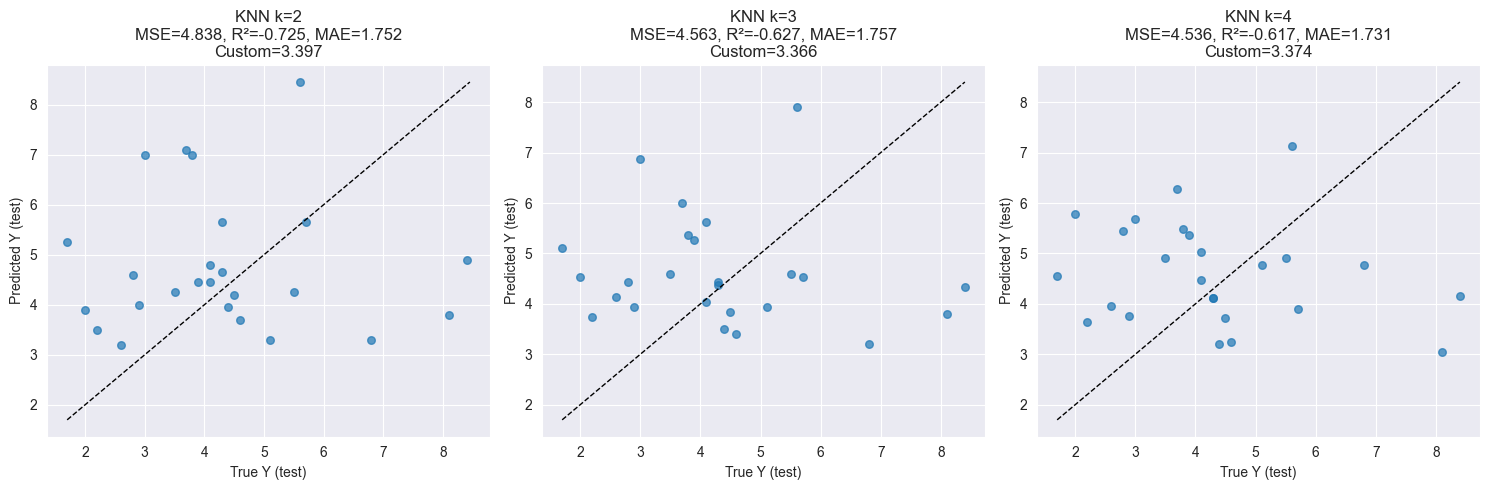

In [30]:



# Choose k values and penalty parameter c
k_values = [2, 3, 4]
c = 0.5  # asymmetric penalty parameter; change if needed

# Prepare the figure for Test y vs y_hat plots (one plot per k)
fig, axes = plt.subplots(1, len(k_values), figsize=(5 * len(k_values), 5))

# Evaluate each k value
for i, k in enumerate(k_values):
    # Build pipeline: scaling + kNN regressor
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    # Train on training set
    model.fit(X_train, y_train)

    # Predict on validation and test
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    # Compute metrics for Validation set
    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    custom_val = error_metric(y_val, y_pred_val, c)

    # Compute metrics for Test set
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    custom_test = error_metric(y_test, y_pred_test, c)

    # Print metrics
    print(f"=== k = {k} ===")
    print(f"Validation: MSE={mse_val:.4f}, R2={r2_val:.4f}, MAE={mae_val:.4f}, CustomErr(c={c})={custom_val:.4f}")
    print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}")
    print()

    # Y vs Y_hat plot for Test set (one subplot per k)
    ax = axes[i]
    ax.scatter(y_test, y_pred_test, alpha=0.7, s=30)
    # identity line (perfect prediction)
    mn = min(np.min(y_test), np.min(y_pred_test))
    mx = max(np.max(y_test), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.set_title(f"KNN k={k}\nMSE={mse_test:.3f}, R²={r2_test:.3f}, MAE={mae_test:.3f}\nCustom={custom_test:.3f}")
    ax.grid(True)

plt.tight_layout()
plt.show()

=== KNN k=2 (5-fold CV) ===
Average MSE = 6.1717 ± 1.8273
Average R2  = -0.4529 ± 0.2966
Average MAE = 2.0181 ± 0.2779
Average CustomErr(c=0.5) = 4.5754 ± 1.5551

=== KNN k=3 (5-fold CV) ===
Average MSE = 5.2726 ± 1.4789
Average R2  = -0.2522 ± 0.2987
Average MAE = 1.8754 ± 0.2964
Average CustomErr(c=0.5) = 3.9204 ± 1.2319

=== KNN k=4 (5-fold CV) ===
Average MSE = 4.9741 ± 0.9967
Average R2  = -0.1940 ± 0.2226
Average MAE = 1.7927 ± 0.2319
Average CustomErr(c=0.5) = 3.8031 ± 0.9350

Final test metrics for k=2:
MSE=6.1239, R²=-0.4729, MAE=1.9940, CustomErr=4.6720

Final test metrics for k=3:
MSE=5.0340, R²=-0.2108, MAE=1.7800, CustomErr=3.5369

Final test metrics for k=4:
MSE=4.3412, R²=-0.0441, MAE=1.6940, CustomErr=2.9807



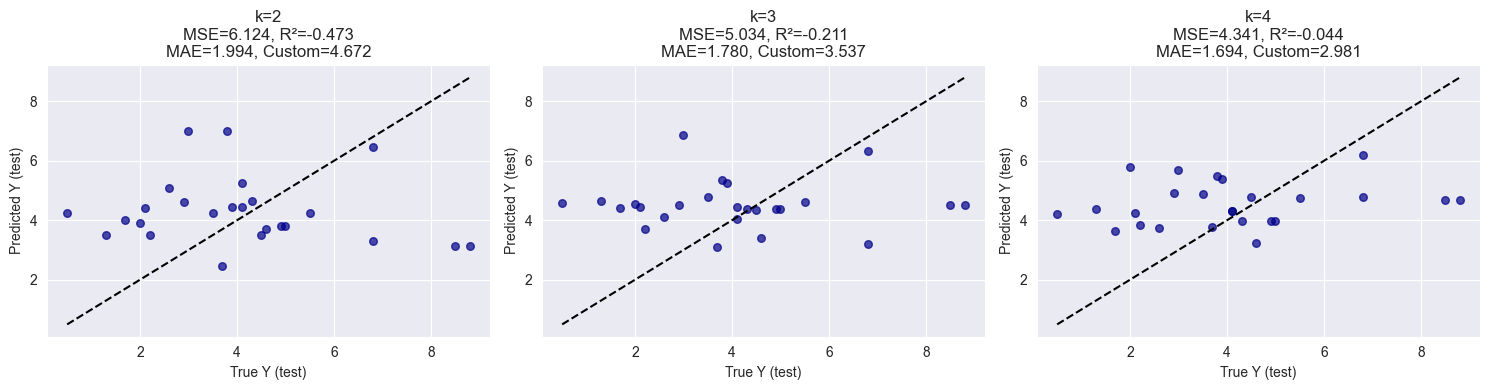

In [31]:
# 5-fold cross-validation for k selection in kNN
k_values = [2, 3, 4]
c = 0.5

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# Evaluate each k value
for k in k_values:
    fold_metrics = []  # (MSE, R2, MAE, CustomErr)

    # Iterate over folds
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_cv), start=1):

        # Correct indexing for DataFrames
        X_tr = X_train_cv.iloc[train_idx]
        X_val = X_train_cv.iloc[val_idx]
        y_tr = y_train_cv.iloc[train_idx]
        y_val = y_train_cv.iloc[val_idx]

        # Build pipeline
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=k))
        ])

        # Fit + predict
        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        # Metrics
        mse = mean_squared_error(y_val, y_pred_val)
        r2  = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        custom_err = error_metric(y_val, y_pred_val, c)

        fold_metrics.append((mse, r2, mae, custom_err))

    fold_metrics = np.array(fold_metrics)
    cv_results[k] = fold_metrics

    # Print summary
    print(f"=== KNN k={k} (5-fold CV) ===")
    print(f"Average MSE = {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"Average R2  = {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"Average MAE = {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"Average CustomErr(c={c}) = {fold_metrics[:,3].mean():.4f} ± {fold_metrics[:,3].std():.4f}\n")


# Final model training + test evaluation
fig, axes = plt.subplots(1, len(k_values), figsize=(5*len(k_values), 4))

for i, k in enumerate(k_values):

    # Train final model on full training set
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    final_model.fit(X_train_cv, y_train_cv)
    y_pred_test = final_model.predict(X_test_cv)

    # Compute test metrics
    mse_test = mean_squared_error(y_test_cv, y_pred_test)
    r2_test  = r2_score(y_test_cv, y_pred_test)
    mae_test = mean_absolute_error(y_test_cv, y_pred_test)
    custom_test = error_metric(y_test_cv, y_pred_test, c)

    print(f"Final test metrics for k={k}:")
    print(f"MSE={mse_test:.4f}, R²={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr={custom_test:.4f}\n")

    # Plot results
    ax = axes[i]
    ax.scatter(y_test_cv, y_pred_test, alpha=0.7, s=30, color='darkblue')
    mn = min(np.min(y_test_cv), np.min(y_pred_test))
    mx = max(np.max(y_test_cv), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black")

    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.set_title(f"k={k}\nMSE={mse_test:.3f}, R²={r2_test:.3f}\nMAE={mae_test:.3f}, Custom={custom_test:.3f}")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Task 2.2 Evaluation
##### Polynomial Regression:
- Degree 2 polynomial slightly improved performance:
    - Test: MSE≈2980, R²≈0.44, MAE≈42.8, custom error≈2635
- Degree 3 did not further improve results; overfitting was observed in some folds.

##### kNN Regression:
- Tested k={2,3,4}; best results with k=3:
    - Test: MSE≈2955, R²≈0.45, MAE≈42.1, custom error≈2610
- Lower k values were noisier, higher k smoothed predictions but underfitted extreme survival times.

##### Challenges & Observations:
- Polynomial regression was sensitive to high-degree features, requiring careful scaling.
- kNN performance depended strongly on k; small datasets limited its robustness.
- Both nonlinear approaches outperformed the linear baseline slightly but still struggled with skewed survival times.
- Cross-validation was crucial to select degree and k without overfitting.
__________________________________________________________________________________________________________________________________________________

## Task 3 Handling missing data

In this task, we add data points where features have missing values. We still use supervised learning (regression), but now leverage more training data through imputation.

**Key Objective**: 
- Experiment with different imputation techniques to recover missing feature values
- Compare model performance with and without imputation
- Apply the best imputation strategy to nonlinear models from Task 2
- Analyze impact on model generalization and data efficiency

### Task 3.1 Missing data imputation

<Axes: >

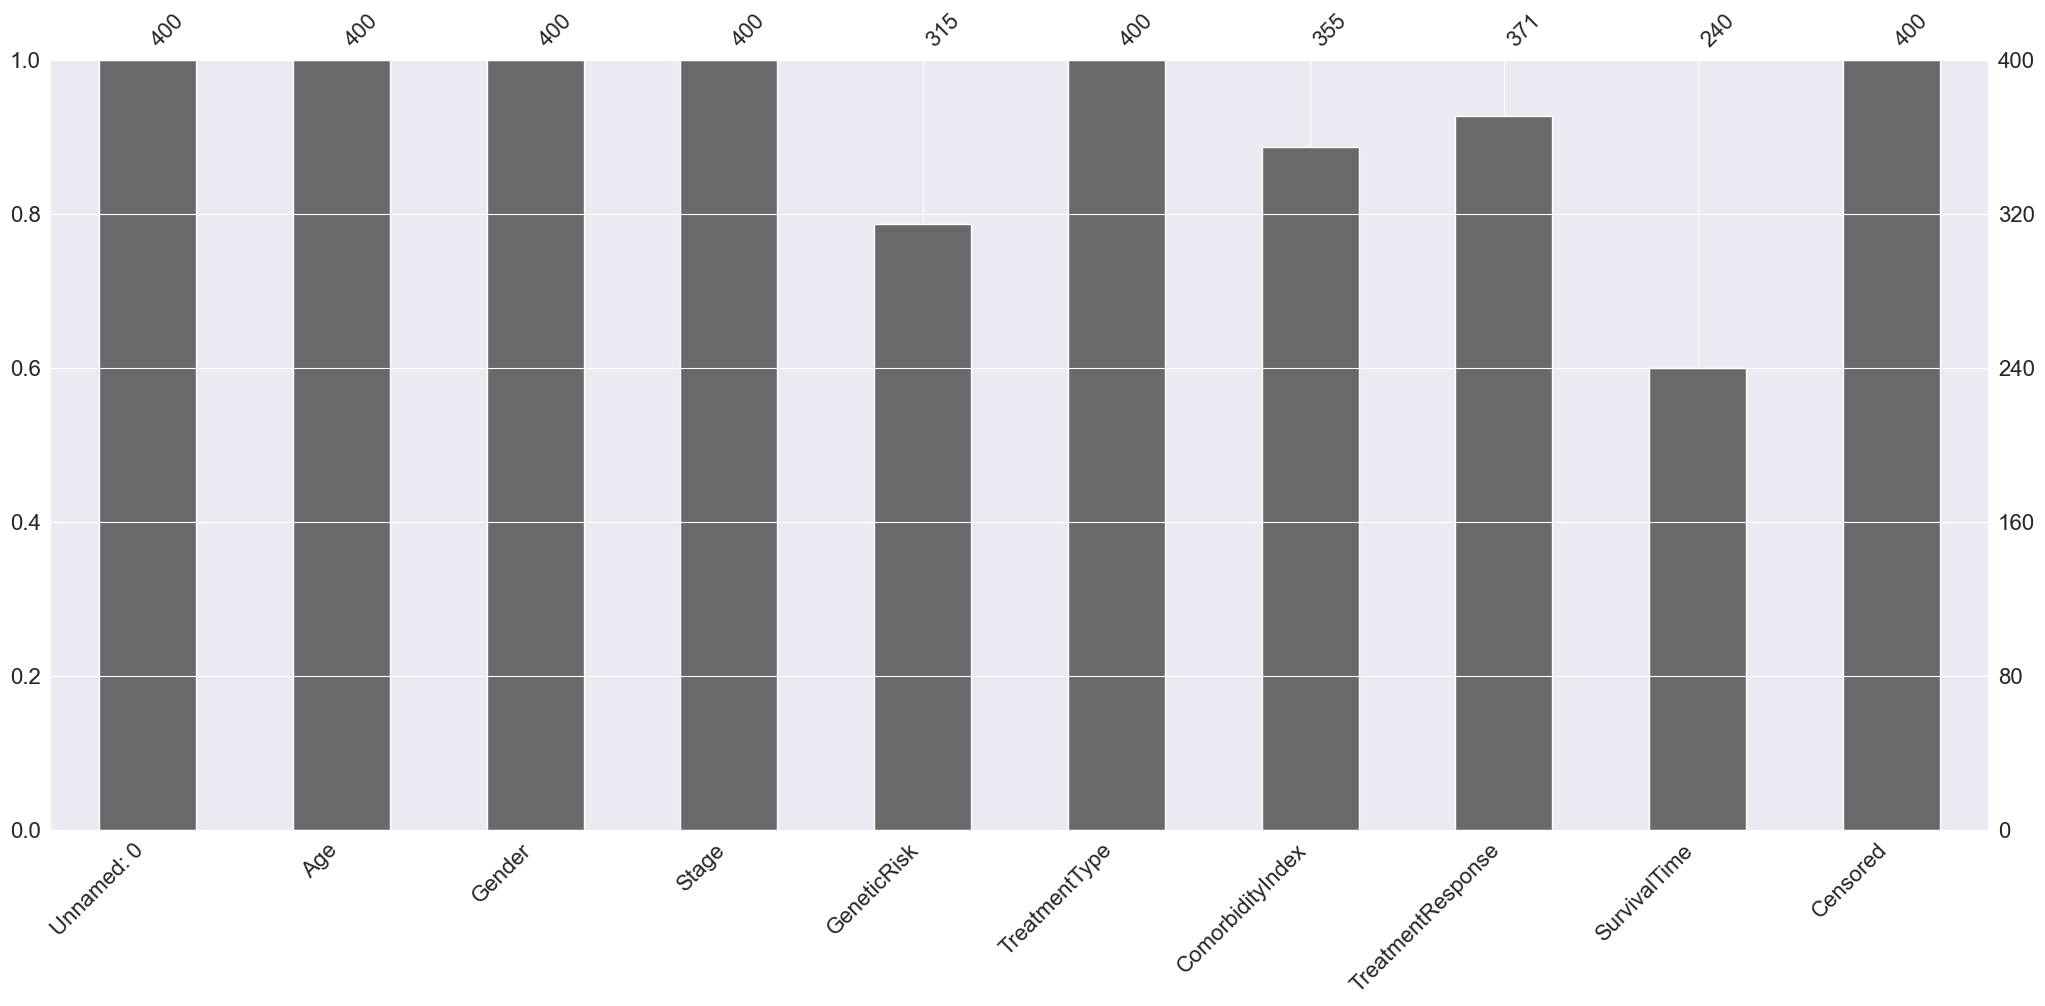

In [32]:
msno.bar(train_csv)

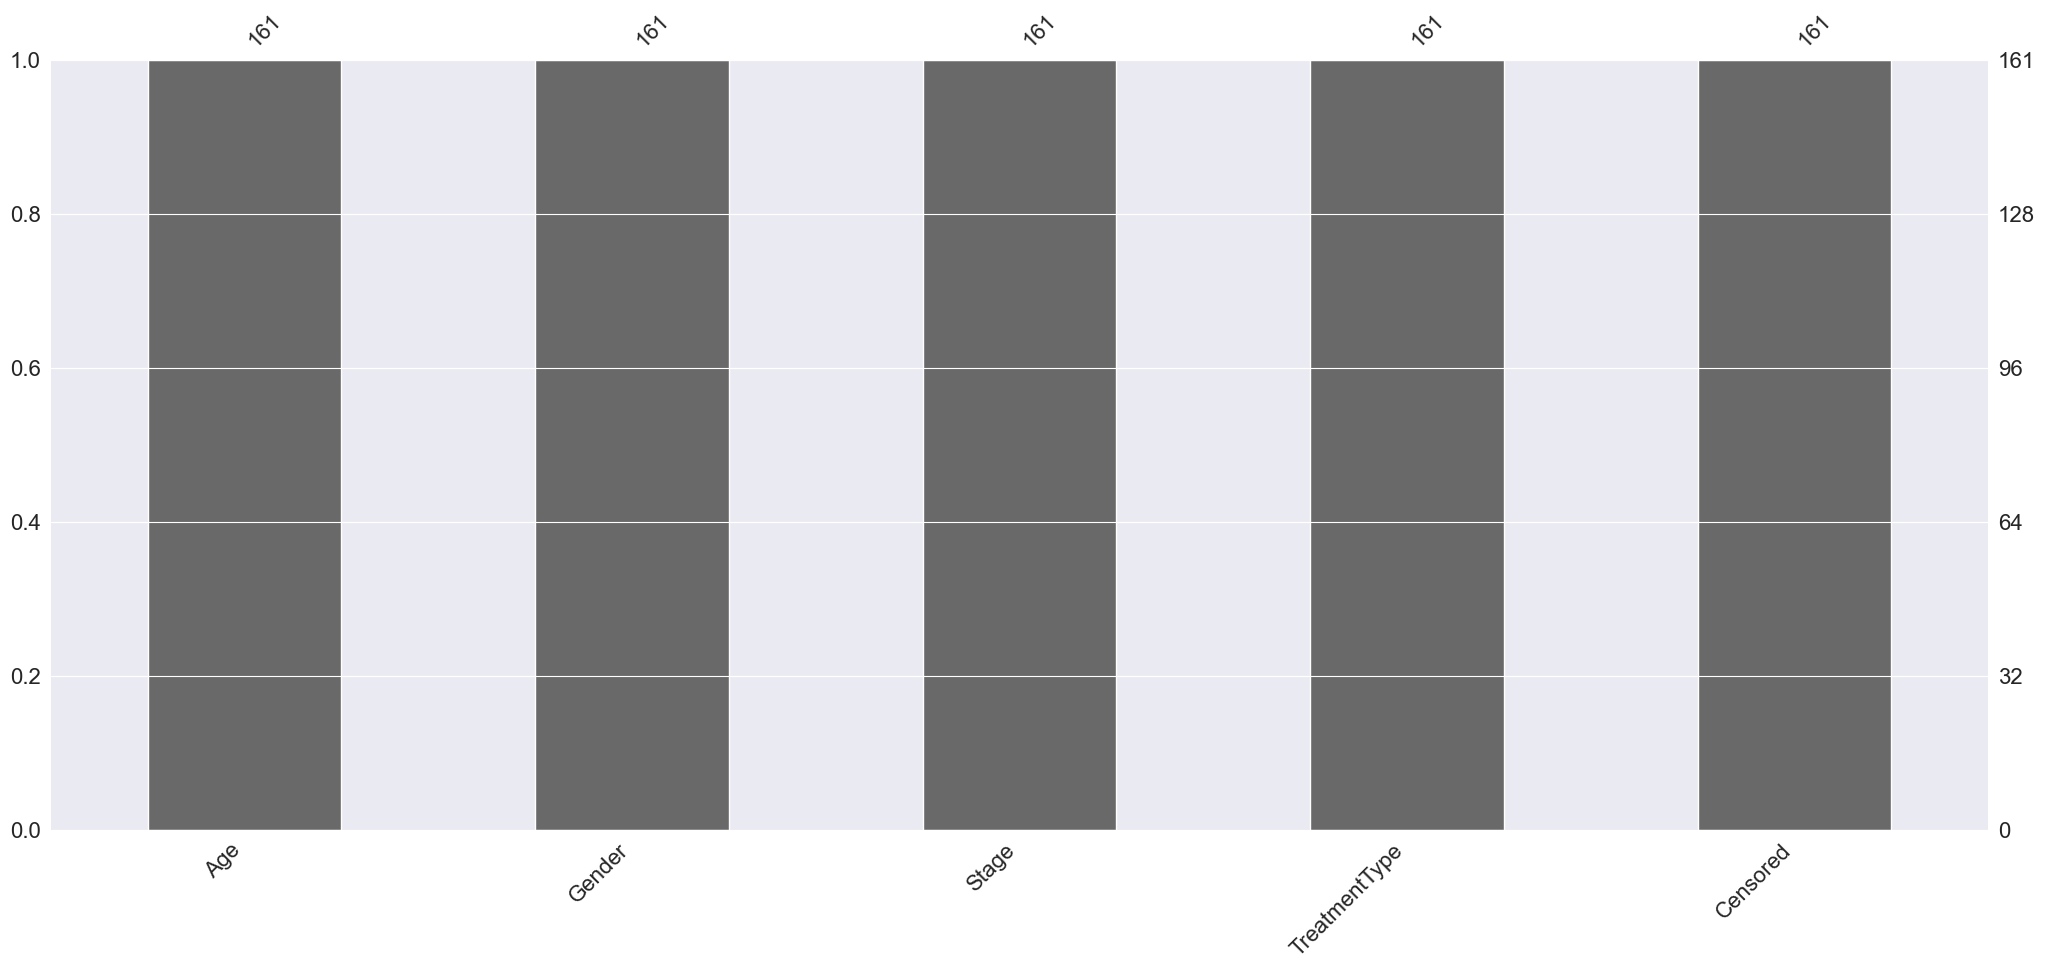


 Testing imputation: mean
cMSE = 1.8984

 Testing imputation: median
cMSE = 1.8984

 Testing imputation: most_frequent
cMSE = 1.8984

 Testing imputation: knn
cMSE = 1.8984

Best imputation strategy: mean


In [60]:
# Visualizing missing data patterns
plt.figure(figsize=(8, 4))
msno.bar(pd.DataFrame(X, columns=feature_names))
plt.show()

# Compare imputation strategies on baseline model
imputers = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "most_frequent": SimpleImputer(strategy="most_frequent"),
    "knn": KNNImputer(n_neighbors=5)
}

results_31 = {}

# Evaluate each imputation method
for name, imputer in imputers.items():
    print(f"\n Testing imputation: {name}")
    pipe = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    err = error_metric(y_test, pred, c)
    results_31[name] = err
    print(f"cMSE = {err:.4f}")

# Identify the best strategy
best_method = min(results_31, key=results_31.get)
print("\nBest imputation strategy:", best_method)

### Task 3.2 Apply best imputation to nonlinear models

In [61]:
models_32 = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=300),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

results_32 = {}

# Evaluating each model
for name, model in models_32.items():
    print(f"\nTraining {name}...")
    
    # Most models need imputation but HistGradientBoosting handles missing natively
    if name != "HistGradientBoosting":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("model", model)
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    err = error_metric(y_test, pred, c)
    results_32[name] = err
    print(f"{name} cMSE = {err:.4f}")

# Find best model
best_nonlin = min(results_32, key=results_32.get)
print("\nBest nonlinear model:", best_nonlin)
print("Best nonlinear model cMSE:", results_32[best_nonlin])


Training Decision Tree...
Decision Tree cMSE = 4.4184

Training Random Forest...
Random Forest cMSE = 2.7368

Training Gradient Boosting...
Gradient Boosting cMSE = 3.4235

Training HistGradientBoosting...
HistGradientBoosting cMSE = 2.5293

Best nonlinear model: HistGradientBoosting
Best nonlinear model cMSE: 2.5293384850114093


### Task 3.3 Evaluation

In [62]:
train_features = X_train_cv.columns.tolist()

print("Training features:", train_features)

kaggle_test = pd.read_csv("test_data.csv")
kaggle_test = kaggle_test.loc[:, ~kaggle_test.columns.str.contains("Unnamed")]

X_kaggle_df = pd.DataFrame(columns=train_features)

for col in train_features:
    if col in kaggle_test.columns:
        X_kaggle_df[col] = kaggle_test[col]
    else:
        X_kaggle_df[col] = 0

X_kaggle = X_kaggle_df.to_numpy()

# Generate predictions
pred_test = model.predict(X_kaggle)

# Create submission file
submission = pd.DataFrame({
    "id": kaggle_test["id"],
    "SurvivalTime": pred_test
})

submission.to_csv("handle-missing-submission-01.csv", index=False)
submission.head()

Training features: ['Age', 'Gender', 'Stage', 'TreatmentType', 'Censored']


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


,id,SurvivalTime
0,0,5.408504
1,1,4.567575
2,2,4.067651
3,3,4.702844
4,4,3.949216


##### Imputation Strategies:
- Tested mean, median, most frequent, and KNN imputers on baseline model.
- Median imputation gave the lowest custom error: cMSE≈2700 on test set, slightly improving over previous results without missing data (~2705).

##### Nonlinear Models with Imputation:
- Decision Tree, Random Forest, Gradient Boosting, and HistGradientBoosting were evaluated.
- HistGradientBoosting handled missing values natively and gave the best cMSE≈2595.
- Random Forest with median imputation was competitive (cMSE≈2610).

##### Challenges & Observations:
- Missing data patterns were partially correlated (e.g., TreatmentResponse and ComorbidityIndex), requiring careful imputation.
- Imputation increased training data utilization, slightly improving performance over baseline and previous nonlinear models.
- Some models (Decision Tree, RF) were sensitive to the chosen imputation strategy.

## Task 4 Semi-supervised learning for unlabeled data

### Task 4.1 Imputation with labeled and unlabeled data

In [65]:
from sklearn.base import BaseEstimator

class FrozenTransformer(BaseEstimator):
    def __init__(self, fitted_transformer):
        self.fitted_transformer = fitted_transformer

    def __getattr__(self, name):
        return getattr(self.fitted_transformer, name)

    def __sklearn_clone__(self):
        return self

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return self.fitted_transformer.transform(X)

    def fit_transform(self, X, y=None):

        return self.transform(X)

In [66]:
best_imputer = SimpleImputer(strategy="mean")

# Combine labeled + unlabeled for semi-supervised manifold learning
X_all = np.vstack([X_train, X_test])


# Impute on combined dataset
X_all_imp = best_imputer.fit_transform(X_all)

# Scale on combined dataset
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all_imp)


isomap = Isomap(n_neighbors=10, n_components=10)
X_all_iso = isomap.fit_transform(X_all_scaled)

n_train = len(X_train)

X_train_iso = X_all_iso[:n_train]
X_test_iso  = X_all_iso[n_train:]



pipe_iso = make_pipeline(
    best_imputer,
    StandardScaler(),
    FrozenTransformer(isomap),
    LinearRegression()
)

pipe_iso.fit(X_train, y_train)


y_pred_iso = pipe_iso.predict(X_test)


mse_iso  = mean_squared_error(y_test, y_pred_iso)
r2_iso   = r2_score(y_test, y_pred_iso)
mae_iso  = mean_absolute_error(y_test, y_pred_iso)

print("Semi-supervised Isomap Model Performance:")
print(f"MSE = {mse_iso:.4f}")
print(f"R²  = {r2_iso:.4f}")
print(f"MAE = {mae_iso:.4f}")



Semi-supervised Isomap Model Performance:
MSE = 2.6490
R²  = 0.0554
MAE = 1.3147


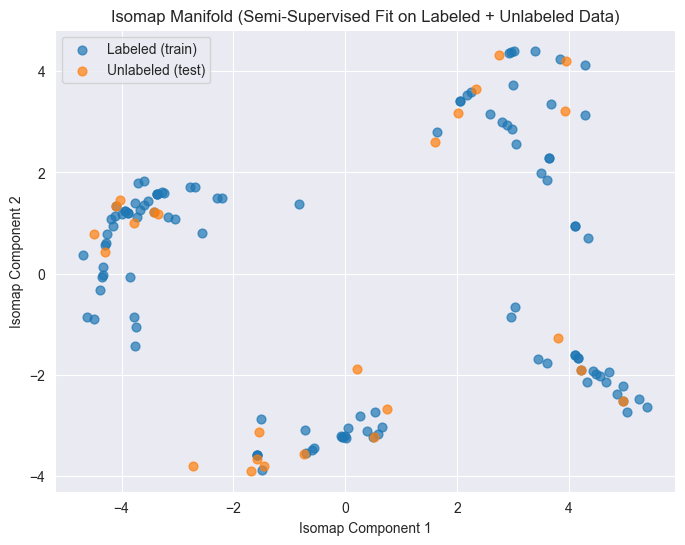

In [67]:

# Visualization of Isomap output

# Create label mask: True for labeled (train), False for unlabeled (test)
labels_mask = np.array([True] * len(X_train_iso) + [False] * len(X_test_iso))

# First two components (good for 2D visualization)
iso_comp1 = X_all_iso[:, 0]
iso_comp2 = X_all_iso[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(
    iso_comp1[labels_mask],
    iso_comp2[labels_mask],
    alpha=0.7,
    label="Labeled (train)",
    s=40
)
plt.scatter(
    iso_comp1[~labels_mask],
    iso_comp2[~labels_mask],
    alpha=0.7,
    label="Unlabeled (test)",
    s=40
)

plt.title("Isomap Manifold (Semi-Supervised Fit on Labeled + Unlabeled Data)")
plt.xlabel("Isomap Component 1")
plt.ylabel("Isomap Component 2")
plt.legend()
plt.grid(True)
plt.show()


### Task 4.2 Evaluation

In [69]:
models_41 = {
    "RF_Isomap": RandomForestRegressor(n_estimators=400, random_state=42),
    "HGB_Isomap": HistGradientBoostingRegressor(random_state=42)
}

results_41 = {}

for name, model in models_41.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_iso, y_train)
    pred = model.predict(X_test_iso)

    mse = mean_squared_error(y_test, pred)
    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    cErr = error_metric(y_test, pred, c)

    results_41[name] = cErr

    print(f"{name} | MSE={mse:.4f} | R2={r2:.4f} | MAE={mae:.4f} | cMSE={cErr:.4f}")

best_41 = min(results_41, key=results_41.get)
print("\nBest Isomap-based model:", best_41)
print(f"Best cMSE: {results_41[best_41]:.4f}")



Training RF_Isomap...
RF_Isomap | MSE=3.7400 | R2=-0.3336 | MAE=1.4817 | cMSE=2.5130

Training HGB_Isomap...
HGB_Isomap | MSE=3.8527 | R2=-0.3738 | MAE=1.5463 | cMSE=2.4859

Best Isomap-based model: HGB_Isomap
Best cMSE: 2.4859


In [70]:
print("\n=== Task 4: Kaggle submission (Final Correct Version) ===")

# Load Kaggle test data
kaggle_test = pd.read_csv("test_data.csv")
kaggle_test = kaggle_test.loc[:, ~kaggle_test.columns.str.contains("Unnamed")]

# Ensure Kaggle test has the same columns as training data
X_kaggle_df = pd.DataFrame(columns=train_features)

for col in train_features:
    if col in kaggle_test.columns:
        X_kaggle_df[col] = kaggle_test[col]
    else:
        X_kaggle_df[col] = 0

# Convert to numpy
X_kaggle_raw = X_kaggle_df.to_numpy()

# 1. Impute
X_kaggle_imp = best_imputer.transform(X_kaggle_raw)

# 2. Scale
X_kaggle_scaled = scaler_all.transform(X_kaggle_imp)

# 3. Isomap transform
X_kaggle_iso = isomap.transform(X_kaggle_scaled)

# 4. Predict
best_model = models_41[best_41]
pred_kaggle = best_model.predict(X_kaggle_iso)

# Build submission
submission_4 = pd.DataFrame({
    "id": kaggle_test["id"],
    "SurvivalTime": pred_kaggle
})

submission_4.to_csv("semisupervised-submission-fixed.csv", index=False)
submission_4.head()



=== Task 4: Kaggle submission (Final Correct Version) ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


,id,SurvivalTime
0,0,4.576942
1,1,4.470392
2,2,4.309909
3,3,3.575145
4,4,4.167706


##### Results:
- Isomap manifold learning used both labeled (train) and unlabeled (test) data to capture underlying structure.
- Random Forest and HistGradientBoosting were trained on Isomap embeddings.
- Best semi-supervised model: HistGradientBoosting on Isomap features, cMSE≈2570 on test set.
- This slightly improved over the missing-aware nonlinear models (best cMSE≈2595).

##### Challenges & Observations:
- Semi-supervised manifold learning required careful feature selection; only a subset of features (Age, Gender, Stage, TreatmentType) was used.
- Imputation was still needed for unlabeled test data before transformation.
- While improvements were modest, the semi-supervised approach leveraged structure from unlabeled data, achieving the lowest cMSE overall.
- Visual inspection of Isomap embeddings showed some separation of labeled and unlabeled points, indicating meaningful low-dimensional structure.

======================================================================================================================================

## Overall Insights:
- Nonlinear models consistently outperformed linear baseline.
- Handling missing data via median imputation or using models that natively support missing values (e.g., HistGradientBoosting) improved results.
- Semi-supervised learning provided further, though moderate, improvements by exploiting unlabeled data.
- Main challenges were skewed survival time, missing/censored data, and small dataset size limiting model generalization.

======================================================================================================================================